# Preparación del dataset y construcción del pipeline

Este notebook recoge el desarrollo inicial del pipeline utilizado en el TFM. En esta primera fase el objetivo principal no es maximizar métricas, sino construir una base experimental estable sobre la que poder iterar más adelante con distintas arquitecturas y configuraciones.

Para ello se utilizan dos datasets del challenge IJCB PAD-ID Card. El entrenamiento y validación se realizan sobre el conjunto ID Cards, mientras que SYN PASS se reserva exclusivamente para evaluación cross-dataset, de forma que permita medir capacidad de generalización sobre países y documentos no vistos durante el entrenamiento.

El problema se plantea como una clasificación binaria entre documentos genuinos y ataques de presentación. Aun así, se mantiene la etiqueta original de cada ataque para poder analizar posteriormente el comportamiento del modelo según el tipo de manipulación.

El dataset presenta además un desbalance importante entre muestras genuinas y ataques. En este primer hito no se aplican todavía estrategias específicas de compensación, ya que el objetivo es obtener primero una baseline reproducible antes de introducir otro tipo de técnicas adicionales.

Para evitar fugas de información, la partición train/validación se realiza a nivel de documento (document_id) y no de imagen individual, evitando así que distintas capturas del mismo documento aparezcan en conjuntos diferentes.

# Instalación de dependencias

Se instalan las librerías necesarias para el pipeline de entrenamiento y evaluación.

Algunas versiones se fijan explícitamente para evitar incompatibilidades entre 'transformers', 'peft' y la implementación LoRA utilizada sobre Vision Transformers durante los experimentos en Colab.

In [ ]:
#Dependencias del Hito 1
!pip install -q \
    transformers==4.40.0 \
    peft==0.10.0 \
    sentence-transformers==2.7.0

!pip install -q -U \
    scipy \
    timm \
    scikit-learn

#Experimentación más avanzada. Instalación de dependencias adicionales.
#Albumentations es el estándar en papers de PAD para augmentation agresiva.
# timm proporciona los backbones DINOv2/CLIP ya preconfigurados.
!pip install -q albumentations>=1.3.0
!pip install -q timm>=0.9.0
!pip install -q open-clip-torch    # CLIP oficial de OpenAI / LAION
!pip install -q transformers>=4.40.0 peft>=0.10.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8

# Importación de librerías

Las librerías se agrupan por bloques según su función dentro del pipeline para mantener el notebook más legible y facilitar la depuración durante los experimentos.

In [ ]:
# Entorno
from google.colab import drive
import os, matplotlib, shutil, zipfile, random, io, csv, cv2, subprocess, gc, open_clip, timm

# Datos
import numpy as np
import pandas as pd
import json

# Visualización
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

from PIL import Image

# Partición y métricas
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    det_curve
)

# Transformers y LoRA
from transformers import (
    ViTForImageClassification,
    SamModel,
    SamProcessor,
    AutoModel,
    AutoImageProcessor,
    CLIPModel,
    CLIPProcessor,
)

from peft import get_peft_model, LoraConfig

# Utilidades
from tqdm.notebook import tqdm

# Albumentations — augmentation avanzada
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configuración del entorno y reproducibilidad

Los experimentos se han ejecutado sobre GPU en Google Colab. En las ejecuciones principales se ha utilizado una NVIDIA A100, aunque el pipeline también puede ejecutarse en GPUs más modestas ajustando el batch size.

Para reducir la variabilidad entre ejecuciones se fijan las semillas de aleatoriedad en PyTorch, NumPy y Python, además de configurar cuDNN en modo determinista.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

if torch.cuda.is_available():
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total',
         '--format=csv,noheader'],
        capture_output=True,
        text=True
    )
    print(result.stdout)
else:
    print("GPU no disponible")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
# Con imágenes siempre a 224x224, benchmark=True deja que cuDNN elija
# el kernel más rápido para cada capa. En A100 se nota bastante.
# Si en algún experimento cambio IMG_SIZE, toca volver a False.
torch.backends.cudnn.benchmark = True

g_loader = torch.Generator()
g_loader.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

Dispositivo: cuda
NVIDIA A100-SXM4-80GB, 81920 MiB



# Carga del dataset

Los datasets se almacenan comprimidos en Google Drive, aunque durante el entrenamiento se trabaja desde almacenamiento local en Colab para evitar penalizaciones de lectura.

Los archivos se descomprimen una única vez en '/content/data_tfm/' y se reutilizan en ejecuciones posteriores si ya existen en disco.

Además, se eliminan automáticamente archivos residuales generados por macOS ('__MACOSX', '.DS_Store') para mantener limpia la estructura del dataset.


In [ ]:
# Montar Google Drive
drive.mount('/content/drive')

# Directorios de trabajo
BASE_DIR = '/content/data_tfm'
DRIVE_TFM = '/content/drive/MyDrive/TFM_ID_Cards'

DIR_IDCARDS = f'{BASE_DIR}/ID_CARDS'
DIR_SYNPASS = f'{BASE_DIR}/SYN_PASS'

os.makedirs(DIR_IDCARDS, exist_ok=True)
os.makedirs(DIR_SYNPASS, exist_ok=True)

# Datasets comprimidos en Drive
datasets = [
    ('ID CARDS', f'{DRIVE_TFM}/Dataset ID CARDS Final.zip', DIR_IDCARDS),
    ('SYN PASS', f'{DRIVE_TFM}/SYN ID PASS Final.zip', DIR_SYNPASS),
]

# Extracción local en Colab
for nombre, zip_path, destino in datasets:

    if not os.path.exists(zip_path):
        raise FileNotFoundError(f'No existe: {zip_path}')

    if not os.listdir(destino):

        print(f'Extrayendo dataset: {nombre}')

        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(destino)

    else:
        print(f'Dataset ya disponible: {nombre}')

# Limpieza de archivos residuales de macOS
removed_files = 0
removed_dirs = 0

for directorio in [DIR_IDCARDS, DIR_SYNPASS]:

    for root, dirs, files in os.walk(directorio, topdown=False):

        for d in dirs:
            if d == '__MACOSX':
                shutil.rmtree(os.path.join(root, d))
                removed_dirs += 1

        for file in files:
            if file == '.DS_Store':
                os.remove(os.path.join(root, file))
                removed_files += 1

print('\nLimpieza finalizada')
print(f'Archivos eliminados: {removed_files}')
print(f'Directorios eliminados: {removed_dirs}')

Mounted at /content/drive
Extrayendo dataset: ID CARDS
Extrayendo dataset: SYN PASS

Limpieza finalizada
Archivos eliminados: 3
Directorios eliminados: 1


## Exploración inicial del dataset

Antes de comenzar el entrenamiento se revisa la estructura de ambos datasets para comprobar que las imágenes se han cargado correctamente y que la distribución de carpetas coincide con la esperada.

En esta fase no se busca todavía extraer métricas complejas, sino detectar posibles problemas básicos de organización, archivos corruptos o directorios vacíos que puedan afectar más adelante al pipeline.

Además del número total de imágenes, también interesa observar cómo se distribuyen las muestras entre categorías, por el desbalanceo mencionado anteriormente entre documentos genuinos y ataques.


In [ ]:
# Extensiones válidas del dataset
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def scan_dataset(nombre, root):
    """
    Recorre el dataset y cuenta cuántas imágenes hay
    en cada subdirectorio.
    """
    counts = {}
    for path, dirs, files in os.walk(root):
        # Ignorar archivos generados automáticamente por macOS
        dirs[:] = [d for d in dirs if d != '__MACOSX']
        n_imgs = sum(
            os.path.splitext(f)[1].lower() in IMG_EXTS
            and not f.startswith('.')
            for f in files
        )
        # Guardar únicamente carpetas que contienen imágenes
        if n_imgs:
            rel_path = os.path.relpath(path, root)
            rel_path = rel_path.replace(os.sep, '/')
            counts[rel_path] = n_imgs
    print(f'\n{nombre}')
    for carpeta, total in sorted(counts.items()):
        print(f'{carpeta}: {total}')
    print(f'\nTOTAL: {sum(counts.values())}\n')
    return counts

# Exploración rápida de ambos datasets
id_counts = scan_dataset(
    'ID CARDS',
    f'{DIR_IDCARDS}/Dataset ID CARDS Final')

syn_counts = scan_dataset(
    'SYN PASS',
    f'{DIR_SYNPASS}/SYN ID PASS Final')


ID CARDS
NTS-2026/cyclegan/print: 3391
NTS-2026/cyclegan/screen: 2033
bonafide-ijcb2025PAD-IDcard/bonafide: 3000
composite-ijcb2025PAD-IDcard/composite: 3000
print-ijcb2025PAD-IDcard/print: 3000
screen-ijcb2025PAD-IDcard/screen: 3000

TOTAL: 17424


SYN PASS
poland/bonafide: 1015
poland/printed: 1016
poland/screen: 1015
portugal/bonafide: 1015
portugal/printed: 1014
portugal/screen: 1014
spain/bonafide: 1015
spain/printed: 1019
spain/screen: 1018

TOTAL: 9141



## Composición del dataset

El dataset ID CARDS contiene cuatro categorías principales: bonafide, print, screen y composite. Para el entrenamiento se agrupan las tres últimas en una única clase de ataque, ya que el problema se plantea como una clasificación binaria.

Aun así, se conserva la etiqueta original de cada ataque para poder analizar posteriormente qué tipos resultan más difíciles de detectar.

En el caso de SYN PASS, tanto las muestras genuinas como los ataques son sintéticos. Esto es importante al interpretar métricas como BPCER, ya que parte del error puede deberse al cambio de dominio entre imágenes reales y generadas artificialmente, y no únicamente a fallos del detector PAD.

In [ ]:
# Carpeta donde se guardarán las figuras generadas
os.makedirs(f'{DRIVE_TFM}/figuras', exist_ok=True)

def obtener_imagen_aleatoria(ruta):
    """Devuelve una imagen aleatoria de una carpeta."""
    archivos = [
        f for f in os.listdir(ruta)
        if os.path.splitext(f)[1].lower() in IMG_EXTS
        and not f.startswith('.')
    ]
    if not archivos:
        return None
    return os.path.join(ruta, random.choice(archivos))


def visualizar_idcards(nombre, estructura, ruta_base, ncols=4, guardar=True):
    """
    Visualiza una muestra aleatoria por categoría para comprobar
    que las imágenes y etiquetas del dataset son coherentes.
    """

    carpetas = sorted(estructura.keys())
    nrows = (len(carpetas) + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 3.2, nrows * 3)
    )

    axes = np.array(axes).reshape(-1)
    fig.suptitle(nombre)

    for i, carpeta in enumerate(carpetas):

        ruta = os.path.join(
            ruta_base,
            carpeta.replace('/', os.sep)
        )

        img = obtener_imagen_aleatoria(ruta)

        if img:
            axes[i].imshow(mpimg.imread(img))
            axes[i].set_title(
                carpeta.split('/')[-1],
                fontsize=9
            )

        axes[i].axis('off')

    # Ocultar ejes vacíos si sobran subplots
    for ax in axes[len(carpetas):]:
        ax.axis('off')

    plt.tight_layout()

    # Guardar automáticamente las figuras generadas
    if guardar:
        fig.savefig(
            f'{DRIVE_TFM}/figuras/muestras_{nombre}.png',
            dpi=150,
            bbox_inches='tight'
        )

    plt.show()

# Definición de etiquetas

El problema se plantea como una clasificación binaria entre documentos genuinos y ataques. Aun así, se conserva el tipo original de ataque para poder analizar después el comportamiento del modelo en escenarios concretos.

La partición train/validation se realiza a nivel de documento (document_id) y no de imagen individual, evitando así que distintas capturas del mismo documento aparezcan en conjuntos diferentes y produzcan fuga de información.

Como los 'document_id' se infieren directamente a partir del nombre del archivo, más adelante se realiza una comprobación manual y estadística para verificar que la agrupación es consistente.

In [ ]:
# Conversión a problema binario:
# 0 - genuino
# 1 - ataque
etiquetas = {
    'bonafide': 0,
    'print': 1,
    'printed': 1,
    'screen': 1,
    'composite': 1
}

def etiquetar_dataset(ruta_base, incluir_pais=False):
    """
    Recorre el dataset y genera un DataFrame con:
    ruta, tipo de ataque, etiqueta binaria y document_id.
    """
    registros = []
    for ruta, dirs, archivos in os.walk(ruta_base):
        # Ignorar carpetas residuales de macOS
        dirs[:] = [d for d in dirs if d != '__MACOSX']
        for archivo in archivos:
            # Saltar archivos que no sean imágenes
            if os.path.splitext(archivo)[1].lower() not in IMG_EXTS:
                continue
            partes = os.path.relpath(
                ruta,
                ruta_base
            ).split(os.sep)
            # Detectar automáticamente el tipo de muestra
            tipo = next(
                (p for p in partes if p in etiquetas),
                None
            )
            if tipo is None:
                continue

            registros.append({
                'ruta': os.path.join(ruta, archivo),
                'tipo': tipo,
                'etiqueta_binaria': etiquetas[tipo],
                # El document_id se infiere del nombre del archivo
                'document_id': archivo.split('_')[0],
                # En SYN PASS también interesa conservar el país
                **(
                    {'pais': partes[0]}
                    if incluir_pais else {}
                )
            })

    return pd.DataFrame(registros)

In [ ]:
df_idcards = etiquetar_dataset(
    f'{DIR_IDCARDS}/Dataset ID CARDS Final'
)

df_synpass = etiquetar_dataset(
    f'{DIR_SYNPASS}/SYN ID PASS Final',
    incluir_pais=True
)

print(f'ID CARDS: {len(df_idcards)} imágenes')
print(f'SYN PASS: {len(df_synpass)} imágenes')

ID CARDS: 17424 imágenes
SYN PASS: 9141 imágenes


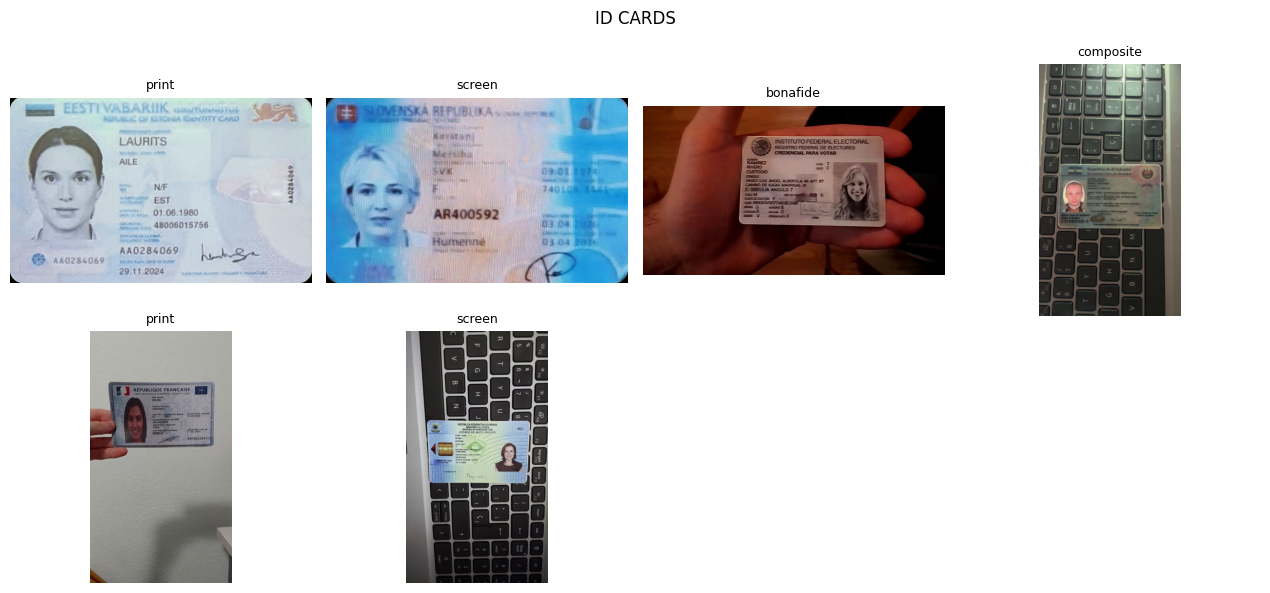

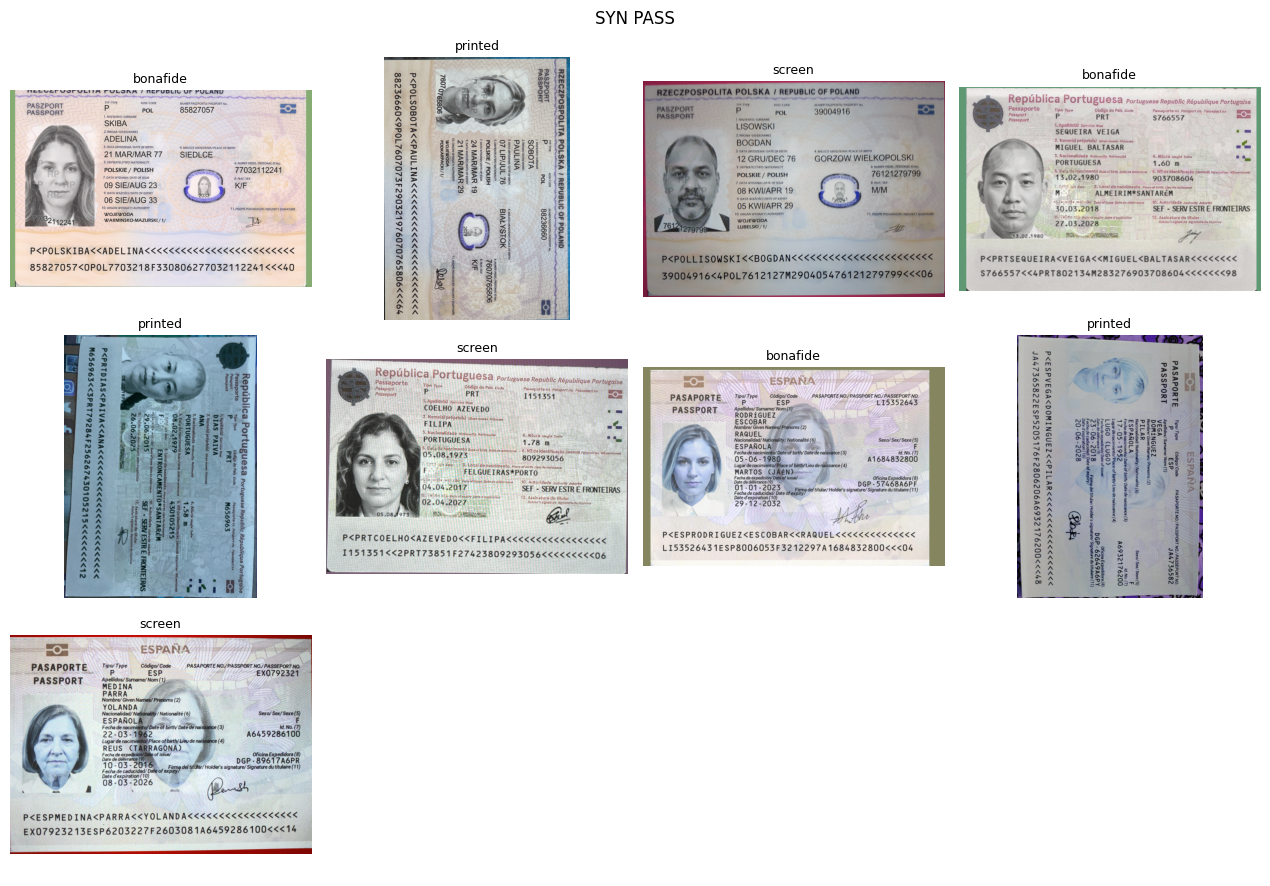

In [ ]:
visualizar_idcards(
    'ID CARDS',
    id_counts,
    f'{DIR_IDCARDS}/Dataset ID CARDS Final'
)

visualizar_idcards(
    'SYN PASS',
    syn_counts,
    f'{DIR_SYNPASS}/SYN ID PASS Final'
)

# Verificación de document_id y distribución del dataset

Una vez generado el DataFrame, se comprueba que la heurística utilizada para construir los 'document_id' sea consistente.

El objetivo es evitar agrupaciones incorrectas que puedan provocar fuga de información entre entrenamiento y validación, especialmente cuando existen múltiples capturas del mismo documento.

Además de la validación automática, también se realiza una inspección manual sobre muestras aleatorias para comprobar visualmente que la agrupación es coherente.

In [ ]:
# Comprobar que los document_id generados sean razonables
doc_sizes = df_idcards.groupby('document_id').size()

print(f'Documentos únicos: {len(doc_sizes)}')
print(f'Tamaño máximo de grupo: {doc_sizes.max()}')

# Detectar agrupaciones anómalas
if doc_sizes.max() >= 200:
    print(f' document_id con muchas imágenes: '
          f'{doc_sizes.idxmax()} ({doc_sizes.max()} imágenes)')
    print('Puede ser un prefijo compartido en el nombre de archivo.')
    print('Revisar si afecta a la partición train/val.')
else:
    print('Tamaño de grupos correcto')
# Verificar que un mismo document_id no mezcle clases
mixed = (
    df_idcards
    .groupby('document_id')['etiqueta_binaria']
    .nunique()
)

ids_con_mezcla = mixed[mixed > 1]

if len(ids_con_mezcla) > 0:
    print(f'AVISO: {len(ids_con_mezcla)} document_id con mezcla de clases')
    print('Puede ser un rasgo del dataset (mismo doc genuino y atacado)')
    print(ids_con_mezcla.head(10))
else:
    print('Verificación de document_id OK')

def inspeccionar_documentos(df, nombre, n=5):
    """
    Muestra ejemplos aleatorios para revisar manualmente
    cómo se generan los document_id.
    """
    print(f'\n{nombre}')
    for tipo in df['tipo'].unique():
        subset = df[df['tipo'] == tipo]
        muestras = subset['ruta'].sample(
            min(n, len(subset)),
            random_state=SEED
        )
        print(f'\n{tipo}')
        for ruta in muestras:
            archivo = os.path.basename(ruta)
            doc_id = (
                archivo.split('_')[0]
                if '_' in archivo else archivo
            )
            print(f'{archivo} - {doc_id}')


# Inspección manual sobre ejemplos aleatorios
inspeccionar_documentos(df_idcards, 'ID CARDS')
inspeccionar_documentos(df_synpass, 'SYN PASS')

# Estadísticas básicas de agrupación
print('\nID CARDS')
print(df_idcards.groupby('document_id').size().describe())

print('\nSYN PASS')
print(df_synpass.groupby('document_id').size().describe())

# Verificar que no existan document_id compartidos
# entre entrenamiento y evaluación externa
ids_idcards = set(df_idcards['document_id'])
ids_synpass = set(df_synpass['document_id'])

interseccion = ids_idcards.intersection(ids_synpass)

print(f'\nDocument IDs compartidos: {len(interseccion)}')

if interseccion:
    print(list(interseccion)[:10])

# Distribución de muestras por categoría
print('\nID CARDS')
print(df_idcards['tipo'].value_counts())

print('\nSYN PASS (país y tipo)')
print(df_synpass.groupby(['pais', 'tipo']).size())

print('\nID CARDS (binario)')
print(df_idcards['etiqueta_binaria'].value_counts())

print('\nSYN PASS (binario)')
print(df_synpass['etiqueta_binaria'].value_counts())

Documentos únicos: 12002
Tamaño máximo de grupo: 4405
 document_id con muchas imágenes: DLC2021 (4405 imágenes)
Puede ser un prefijo compartido en el nombre de archivo.
Revisar si afecta a la partición train/val.
Verificación de document_id OK

ID CARDS

bonafide
703.png - 703.png
2543.png - 2543.png
1799.png - 1799.png
1013.png - 1013.png
2147.png - 2147.png

composite
10293.png - 10293.png
10544.png - 10544.png
9440.png - 9440.png
9735.png - 9735.png
11412.png - 11412.png

print
DLC2021__fin_id__07or0003__000109.jpg - DLC2021
6058.png - 6058.png
MIDV2020__fin_id__26__000145.jpg - MIDV2020
DLC2021__esp_id__05or0003__000061.jpg - DLC2021
7299.png - 7299.png

screen
4803.png - 4803.png
DLC2021__fin_id__07or0004__000109.jpg - DLC2021
4849.png - 4849.png
3490.png - 3490.png
3805.png - 3805.png

SYN PASS

printed
4cc22872-def9-11ef-a48f-dd6fedac92d7_2025-01-30_10-59-38.png - 4cc22872-def9-11ef-a48f-dd6fedac92d7
3f665ad0-d6d0-11ef-a48f-dd6fedac92d7_2025-01-20_01-45-37.png - 3f665ad0-d6d0-11

## Análisis exploratorio del dataset

Con los DataFrames ya construidos se analiza la distribución real de clases,
el desbalance entre genuinos y ataques, y cómo se reparten las imágenes entre documentos.

Estos análisis sirven de base para justificar decisiones posteriores como
la estrategia de partición, el uso de augmentation o la interpretación de métricas
como APCER y BPCER en escenarios desbalanceados.

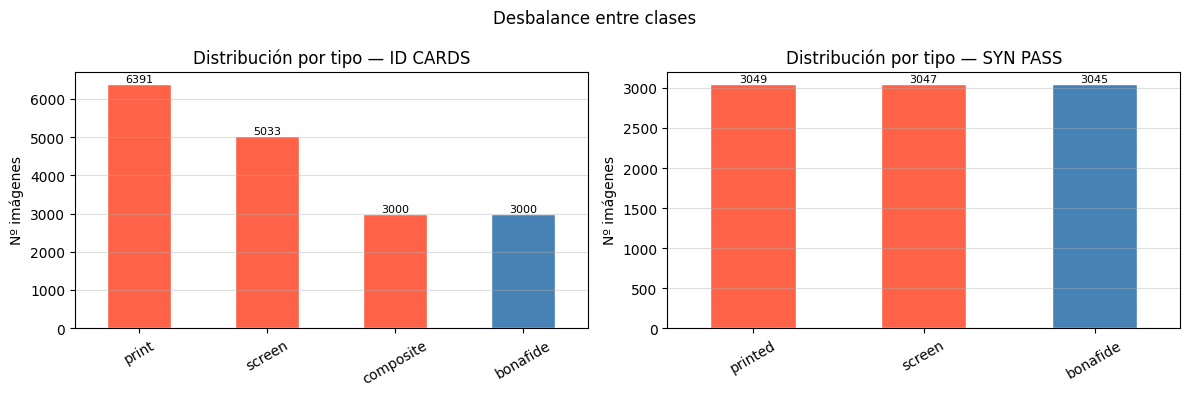

ID CARDS — Genuinos: 3000 | Ataques: 14424 | Ratio: 4.81x
SYN PASS — Genuinos: 3045 | Ataques: 6096 | Ratio: 2.00x


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, nombre) in zip(axes, [
    (df_idcards, 'ID CARDS'),
    (df_synpass, 'SYN PASS')
]):
    conteo = df['tipo'].value_counts()
    colores = ['steelblue' if t == 'bonafide' else 'tomato'
               for t in conteo.index]

    conteo.plot(kind='bar', ax=ax, color=colores, edgecolor='white')

    ax.set_title(f'Distribución por tipo — {nombre}')
    ax.set_xlabel('')
    ax.set_ylabel('Nº imágenes')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.4)

    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom', fontsize=8
        )

plt.suptitle('Desbalance entre clases', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_TFM}/figuras/distribucion_clases.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Ratio de desbalance
for df, nombre in [(df_idcards, 'ID CARDS'), (df_synpass, 'SYN PASS')]:
    n_bon = (df['etiqueta_binaria'] == 0).sum()
    n_atk = (df['etiqueta_binaria'] == 1).sum()
    print(f'{nombre} — Genuinos: {n_bon} | Ataques: {n_atk} | Ratio: {n_atk/n_bon:.2f}x')

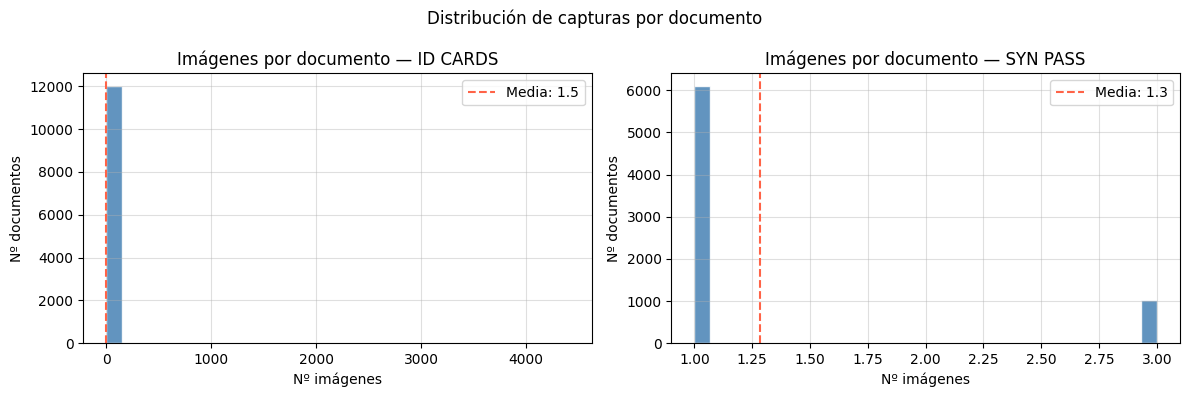

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, nombre) in zip(axes, [
    (df_idcards, 'ID CARDS'),
    (df_synpass, 'SYN PASS')
]):
    imgs_por_doc = df.groupby('document_id').size()

    ax.hist(imgs_por_doc, bins=30, color='steelblue',
            edgecolor='white', alpha=0.85)

    ax.axvline(imgs_por_doc.mean(), color='tomato',
               linestyle='--', label=f'Media: {imgs_por_doc.mean():.1f}')

    ax.set_title(f'Imágenes por documento — {nombre}')
    ax.set_xlabel('Nº imágenes')
    ax.set_ylabel('Nº documentos')
    ax.legend()
    ax.grid(alpha=0.4)

plt.suptitle('Distribución de capturas por documento', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_TFM}/figuras/imgs_por_documento.png',
            dpi=150, bbox_inches='tight')
plt.show()

ID CARDS — Ancho: 720–1920px | Alto: 448–1920px
SYN PASS — Ancho: 623–2018px | Alto: 945–1928px


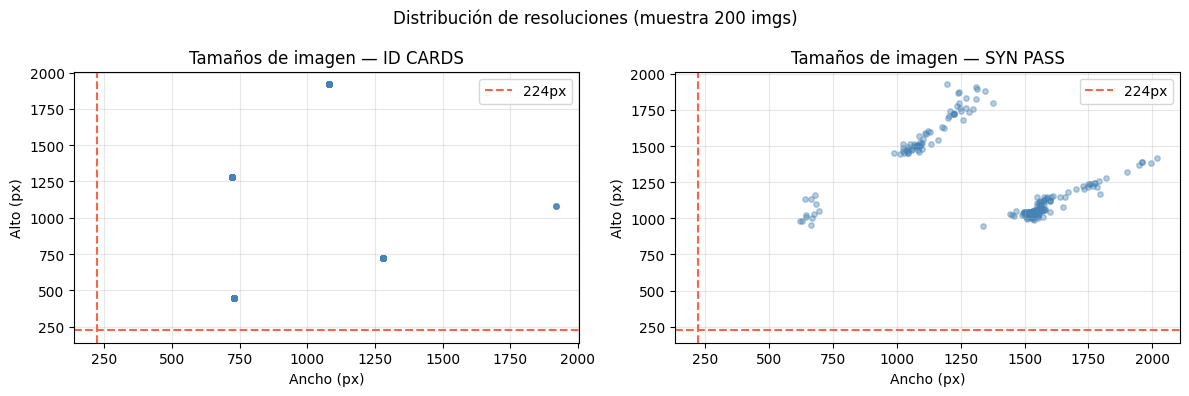

In [ ]:
def muestrear_tamaños(df, n=200):
    muestra = df.sample(min(n, len(df)), random_state=SEED)
    anchos, altos = [], []
    for ruta in muestra['ruta']:
        try:
            w, h = Image.open(ruta).size
            anchos.append(w)
            altos.append(h)
        except Exception:
            pass
    return anchos, altos

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, nombre) in zip(axes, [
    (df_idcards, 'ID CARDS'),
    (df_synpass, 'SYN PASS')
]):
    anchos, altos = muestrear_tamaños(df)

    ax.scatter(anchos, altos, alpha=0.4, s=15, color='steelblue')
    ax.axvline(224, color='tomato', linestyle='--', label='224px')
    ax.axhline(224, color='tomato', linestyle='--')

    ax.set_title(f'Tamaños de imagen — {nombre}')
    ax.set_xlabel('Ancho (px)')
    ax.set_ylabel('Alto (px)')
    ax.legend()
    ax.grid(alpha=0.3)

    print(f'{nombre} — Ancho: {min(anchos)}–{max(anchos)}px | '
          f'Alto: {min(altos)}–{max(altos)}px')

plt.suptitle('Distribución de resoluciones (muestra 200 imgs)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_TFM}/figuras/tamaños_imagen.png',
            dpi=150, bbox_inches='tight')
plt.show()

Exploración inicial del dataset

Antes de entrenar los modelos, revisé un poco cómo estaban organizados ambos datasets para entender mejor qué tipo de imágenes había realmente y detectar posibles problemas antes de empezar con el entrenamiento.

En ID CARDS aparecen 17.424 imágenes, mientras que SYN PASS contiene 9.141. En los dos casos predominan los ataques frente a las muestras genuinas, aunque el desbalance es bastante más fuerte en ID CARDS, donde hay casi cinco veces más ataques que documentos legítimos. Esto es importante porque hace que métricas como la accuracy tengan menos valor por sí solas.

Además, ID CARDS mezcla varias fuentes distintas. Junto al dataset oficial aparecen imágenes generadas mediante CycleGAN dentro de NTS-2026/cyclegan, sobre todo en las categorías print y screen. Es decir, parte de los ataques no son capturas reales, sino sintéticas. Dependiendo de cómo estén generadas, el modelo podría terminar aprendiendo artefactos visuales del propio proceso de generación y no únicamente patrones relacionados con el fraude documental.

También revisé cómo estaban construidos los document_id para evitar fugas entre entrenamiento y validación. En la mayoría de casos cada documento tiene solo una imagen asociada, aunque apareció un caso concreto (DLC2021) con más de 4.000 imágenes bajo el mismo prefijo. No parece un problema grave, pero sí puede alterar ligeramente la distribución entre train y validation dependiendo del split.

Las resoluciones son bastante altas en ambos datasets, así que el resize a 224x224 no debería eliminar demasiada información importante del documento.

En esta fase todavía no se aplica segmentación. Las imágenes incluyen fondo, reflejos, manos y otros elementos externos que podrían introducir sesgos durante el entrenamiento. Precisamente por eso el siguiente paso es probar SAM y comprobar hasta qué punto aislar el documento ayuda realmente al modelo.

# Segmentación con SAM

Antes del entrenamiento se aplica una segmentación previa para reducir la influencia del fondo en las imágenes. En este tipo de datasets de onboarding, el modelo puede aprender correlaciones asociadas al entorno de captura (mesa, iluminación, manos, reflejos) en lugar de centrarse realmente en el documento.

Para minimizar ese efecto se utiliza SAM (Segment Anything Model). El procedimiento es sencillo: se lanza un punto en el centro de la imagen (posición donde normalmente aparece el documento) y se selecciona la máscara con mayor puntuación de IoU entre las propuestas generadas por el modelo.

A partir de esa máscara se obtiene un recorte del documento con un pequeño margen adicional para evitar pérdidas de información en los bordes.

Cuando la segmentación no es fiable (máscara demasiado pequeña o excesivamente grande), el sistema utiliza un fallback conservador basado en un recorte fijo del 8% sobre los bordes de la imagen. La idea no es obtener una segmentación perfecta, sino reducir señales espurias del fondo manteniendo un pipeline estable.

Todo el proceso se ejecuta offline antes del entrenamiento. Las imágenes segmentadas se almacenan en disco y el sistema reutiliza automáticamente los resultados ya procesados en caso de reconexión de Colab.

In [ ]:
print("Cargando SAM...")
sam_processor = SamProcessor.from_pretrained(
    "facebook/sam-vit-base"
)
sam_model = SamModel.from_pretrained(
    "facebook/sam-vit-base"
).to(device)

sam_model.eval()

print(f"SAM listo en {device}")

Cargando SAM...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

SAM listo en cuda


In [ ]:
def segmentar_con_sam(img_pil, margen=8):
    """
    Segmentación mediante SAM usando un punto central.
    Si la máscara no es fiable, se aplica fallback.
    """
    w, h = img_pil.size
    cx, cy = w // 2, h // 2

    # Prompt central
    inputs = sam_processor(
        images=img_pil,
        input_points=[[[cx, cy]]],
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = sam_model(**inputs)

    masks = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu()
    )
    scores = outputs.iou_scores[0, 0].cpu()

    # Máscara con mayor IoU
    best_mask = masks[0][0][scores.argmax()].numpy().astype(bool)

    area_ratio = best_mask.sum() / (h * w)

    # Fallback si la segmentación es poco fiable
    if area_ratio < 0.05 or area_ratio > 0.90:

        mx, my = int(w * 0.08), int(h * 0.08)

        return img_pil.crop((mx, my, w - mx, h - my)), "fallback"

    rows = np.where(best_mask.any(axis=1))[0]
    cols = np.where(best_mask.any(axis=0))[0]

    x1 = max(0, cols[0] - margen)
    y1 = max(0, rows[0] - margen)

    x2 = min(w, cols[-1] + margen)
    y2 = min(h, rows[-1] + margen)

    return img_pil.crop((x1, y1, x2, y2)), "sam"

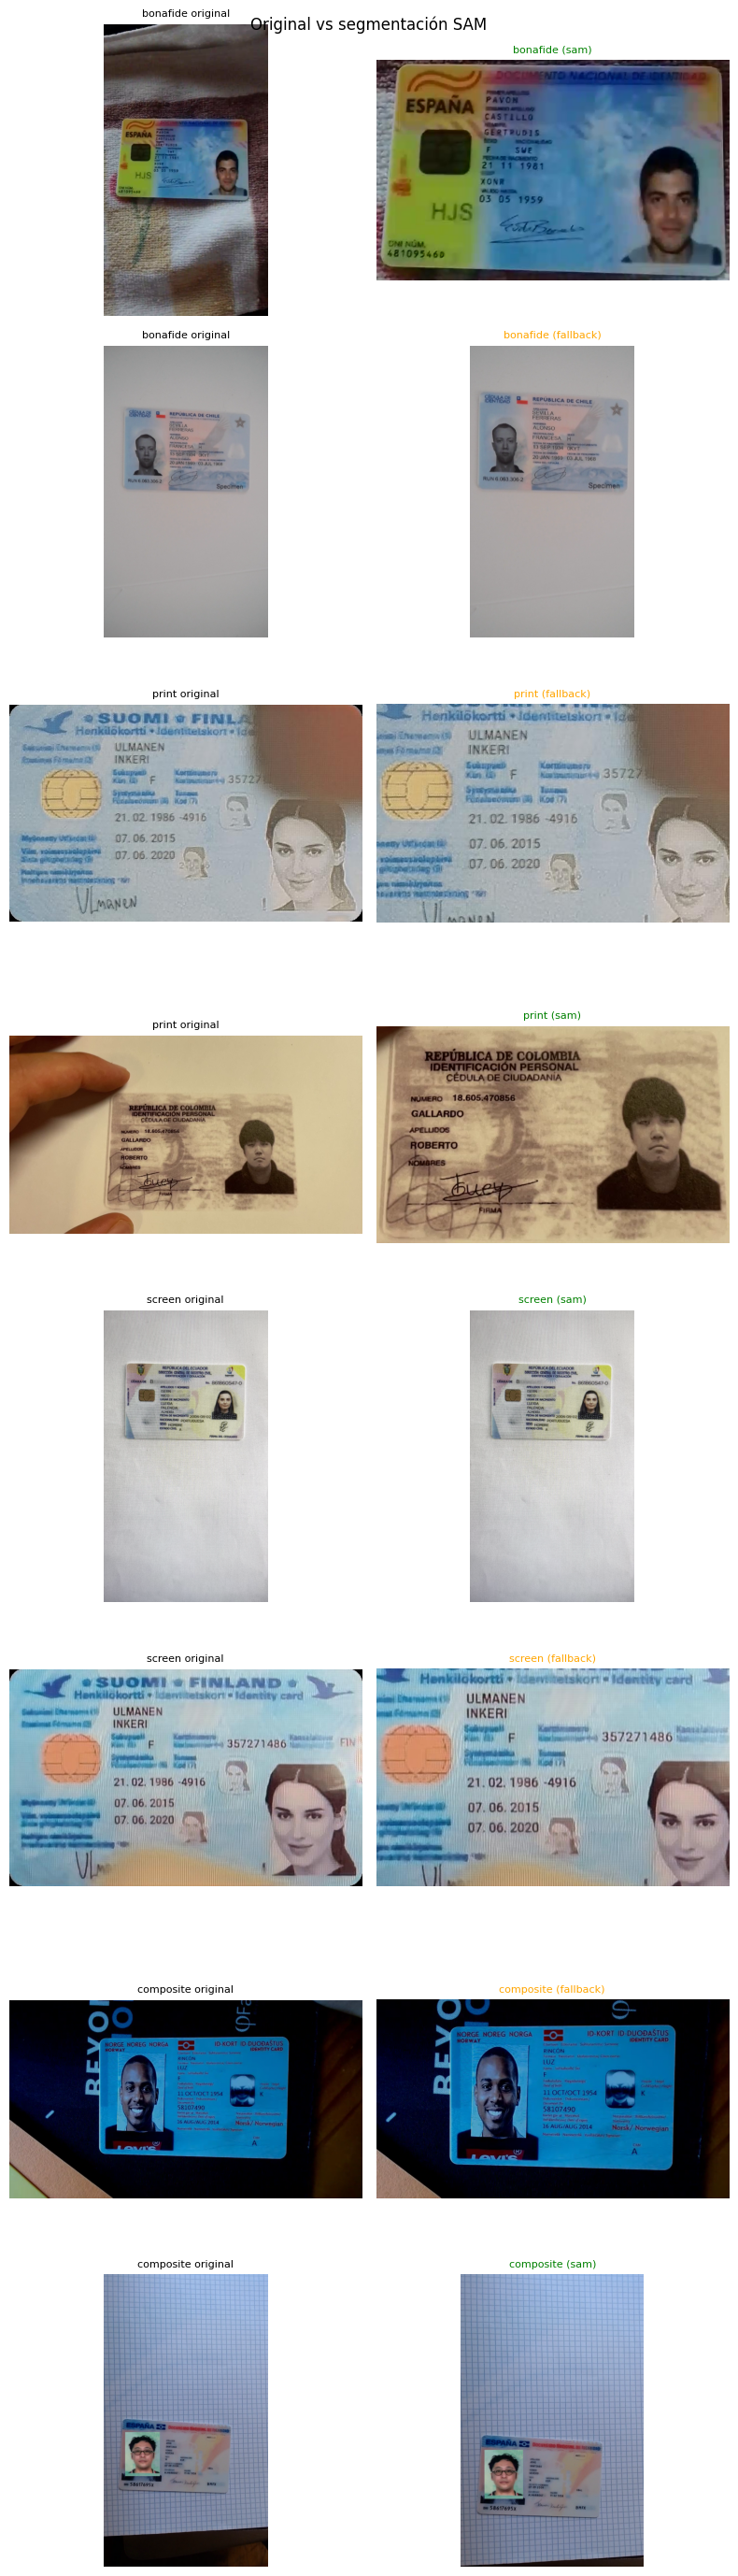

In [ ]:
# Muestras rápidas para comprobar visualmente la segmentación
muestra_test = pd.concat([
    df_idcards[df_idcards['tipo'] == 'bonafide'].sample(2, random_state=42),
    df_idcards[df_idcards['tipo'] == 'print'].sample(2, random_state=42),
    df_idcards[df_idcards['tipo'] == 'screen'].sample(2, random_state=42),
    df_idcards[df_idcards['tipo'] == 'composite'].sample(2, random_state=42),
]).reset_index(drop=True)

fig, axes = plt.subplots(8, 2, figsize=(8, 28))

fig.suptitle(
    "Original vs segmentación SAM",
    fontsize=12
)
for i, (_, row) in enumerate(muestra_test.iterrows()):
    img = Image.open(row['ruta']).convert("RGB")
    img_seg, method = segmentar_con_sam(img)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{row['tipo']} original", fontsize=8)
    axes[i, 0].axis("off")

    color = "green" if method == "sam" else "orange"

    axes[i, 1].imshow(img_seg)
    axes[i, 1].set_title(
        f"{row['tipo']} ({method})",
        fontsize=8,
        color=color
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig(
    f'{DRIVE_TFM}/figuras/test_sam.png',
    dpi=120,
    bbox_inches='tight')
plt.show()

In [ ]:
DIR_SEG = '/content/data_tfm/segmentado'

os.makedirs(DIR_SEG, exist_ok=True)

def preprocesar_sam(df):
    """
    Segmenta imágenes y guarda resultados en disco.
    Registra además el método aplicado:
    sam / fallback / cached / error
    """
    rutas, metodos = [], []

    stats = {
        'sam': 0,
        'fallback': 0,
        'cached': 0,
        'error': 0
    }

    for _, row in tqdm(df.iterrows(), total=len(df)):

        src = row['ruta']

        dst = os.path.join(
            DIR_SEG,
            os.path.relpath(src, '/content/data_tfm')
        )

        os.makedirs(os.path.dirname(dst), exist_ok=True)

        # Reutilizar imagen ya procesada
        if os.path.exists(dst):
            rutas.append(dst)
            metodos.append('cached')
            stats['cached'] += 1
            continue

        try:
            img = Image.open(src).convert('RGB')

            img_out, mode = segmentar_con_sam(img)

            img_out.save(dst)

            rutas.append(dst)
            metodos.append(mode)

            stats[mode] += 1

        except Exception:

            # Si SAM falla, conservar imagen original
            shutil.copy2(src, dst)

            rutas.append(dst)
            metodos.append('error')

            stats['error'] += 1

    df_out = df.copy()

    df_out['ruta'] = rutas
    df_out['seg_method'] = metodos

    return df_out, stats

In [ ]:
print('Procesando ID CARDS...')
df_idcards_seg, stats_idcards = preprocesar_sam(df_idcards)
print(stats_idcards)

print('\nProcesando SYN PASS...')
df_synpass_seg, stats_synpass = preprocesar_sam(df_synpass)
print(stats_synpass)

Procesando ID CARDS...


  0%|          | 0/17424 [00:00<?, ?it/s]

{'sam': 8442, 'fallback': 8982, 'cached': 0, 'error': 0}

Procesando SYN PASS...


  0%|          | 0/9141 [00:00<?, ?it/s]

{'sam': 2548, 'fallback': 6593, 'cached': 0, 'error': 0}


# Análisis del preprocesado con SAM

La segmentación no funciona correctamente en todos los casos. Aproximadamente un 41% de las imágenes utilizan directamente la máscara generada por SAM, mientras que el resto recurren al mecanismo de fallback.

La diferencia entre datasets es especialmente visible en SYN PASS, donde la tasa de fallback es considerablemente mayor. Probablemente esto se deba a diferencias de composición entre imágenes reales y sintéticas, lo que hace que el prompt central resulte menos estable en este dominio.

Aun así, el fallback evita fallos completos del pipeline y mantiene un recorte conservador del documento. En este primer hito el objetivo no es obtener una segmentación precisa, sino reducir parcialmente la influencia del fondo y analizar si esto ayuda a estabilizar el aprendizaje del modelo.

In [ ]:
# Actualizar datasets con rutas segmentadas
df_idcards_seg['ruta_original'] = df_idcards['ruta']
df_synpass_seg['ruta_original'] = df_synpass['ruta']

df_idcards = df_idcards_seg.copy()
df_synpass = df_synpass_seg.copy()

print(
    f"Dataset actualizado: "
    f"{len(df_idcards)} ID CARDS | "
    f"{len(df_synpass)} SYN PASS"
)

# Backup persistente en Drive
DIR_SEG_BACKUP = f'{DRIVE_TFM}/segmentado'

if os.path.exists(DIR_SEG):

    if not os.path.exists(DIR_SEG_BACKUP):
        shutil.copytree(DIR_SEG, DIR_SEG_BACKUP)
        print("Backup creado")

    else:
        print("Backup ya existente")

Dataset actualizado: 17424 ID CARDS | 9141 SYN PASS
Backup ya existente


In [ ]:
# Liberar memoria GPU antes del entrenamiento

del sam_model
del sam_processor

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    free_mem = torch.cuda.mem_get_info()[0] / 1e9

    print(f"VRAM disponible: {free_mem:.2f} GB")

VRAM disponible: 84.53 GB


#Preprocesado y aumento de datos

Todas las imágenes se procesan a una resolución de 224x224 píxeles para mantener coherencia entre arquitecturas.

En Vision Transformer (ViT), esta resolución coincide con el diseño original basado en parches de 16x16, generando 196 tokens de entrada. Modificarla obliga a interpolar embeddings posicionales, lo que puede alterar parcialmente el comportamiento del modelo.

En ResNet-50 la arquitectura es más flexible respecto al tamaño de entrada, pero se mantiene la misma resolución para asegurar una comparación consistente entre modelos.

Aumento de datos

El aumento de datos busca simular variabilidad real en capturas móviles, no simplemente “generar más imágenes”.

Las transformaciones introducen pequeñas variaciones de perspectiva, iluminación, compresión JPEG o desenfoque, situaciones frecuentes en escenarios reales de onboarding.

Se evitan augmentations agresivos porque gran parte del problema depende de detalles estructurales del documento, como texto, layout o MRZ. Alterar excesivamente estas regiones podría eliminar señales relevantes para la detección.

Validación y test

En validación y test no se aplican augmentations. Únicamente se realiza un redimensionado a 256 px seguido de un recorte central a 224 px para mantener una evaluación estable y comparable entre modelos.

In [ ]:
def jpeg_compress(img):
    """
    Simula artefactos de compresión JPEG.
    """
    img = img.convert('RGB')

    buf = io.BytesIO()

    img.save(
        buf,
        format='JPEG',
        quality=random.randint(40, 95)
    )

    buf.seek(0)

    return Image.open(buf).copy().convert('RGB')

In [ ]:
IMG_SIZE = 224

transform_train = transforms.Compose([
  # Geometría
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.9, 1.0)
    ),

    transforms.RandomHorizontalFlip(0.2),

    transforms.RandomRotation(
        10,
        fill=(255, 255, 255)
    ),

    transforms.RandomPerspective(
        distortion_scale=0.1,
        p=0.2
    ),

    # Simular compresión móvil
    transforms.RandomApply([
        transforms.Lambda(jpeg_compress)
    ], p=0.3),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.05
    ),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 1.5)
        )
    ], p=0.3),
    #variaciones menores
    transforms.RandomGrayscale(0.05),
    #tensores y normalización
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

Dataset personalizado

Se implementa una clase Dataset sencilla para centralizar la carga de imágenes y la aplicación de transformaciones.

Además de la imagen y la etiqueta binaria, el dataset conserva información auxiliar como el tipo de ataque y la ruta original. Estos metadatos serán útiles posteriormente para análisis por categorías y evaluación detallada de errores.

La implementación también incorpora un manejo básico de errores durante la lectura de imágenes para evitar interrupciones del pipeline ante archivos corruptos o inconsistentes.

In [ ]:
class DocumentDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        path = row['ruta']

        label = int(row['etiqueta_binaria'])

        tipo = row['tipo']

        try:
            image = Image.open(path).convert('RGB')

        # Si una imagen falla, devolver imagen vacía
        except Exception:

            image = Image.new(
                'RGB',
                (IMG_SIZE, IMG_SIZE),
                color=(0, 0, 0)
            )

        if self.transform:
            image = self.transform(image)

        return image, label, tipo, path

## Partición del dataset

La partición se realiza con GroupShuffleSplit, asegurando que todas las imágenes asociadas a un mismo document_id permanezcan en el mismo conjunto.

Esto evita fuga de información entre entrenamiento y validación, ya que múltiples capturas del mismo documento pueden compartir características visuales muy similares.

SYN PASS no se particiona y se utiliza directamente como conjunto de test externo para evaluar capacidad de generalización fuera de dominio.

In [ ]:
def dividir_idcards(df, test_size=0.2):

    splitter = GroupShuffleSplit(
        test_size=test_size,
        random_state=SEED
    )

    train_idx, val_idx = next(
        splitter.split(
            df,
            groups=df['document_id']
        )
    )

    train_df = df.iloc[train_idx].reset_index(drop=True)

    val_df = df.iloc[val_idx].reset_index(drop=True)

    return train_df, val_df


# Mantener metadatos - tipo y ruta -  para análisis posteriores
def collate_fn(batch):

    imgs, labels, tipos, paths = zip(*batch)

    return (
        torch.stack(imgs),
        torch.tensor(labels, dtype=torch.long),
        list(tipos),
        list(paths)
    )

train_idcards, val_idcards = dividir_idcards(df_idcards)

test_synpass = df_synpass.copy()

train_dataset = DocumentDataset(
    train_idcards,
    transform=transform_train
)

val_dataset = DocumentDataset(
    val_idcards,
    transform=transform_val
)

test_dataset = DocumentDataset(
    test_synpass,
    transform=transform_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn,
    worker_init_fn=seed_worker,
    generator=g_loader
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

print(f"Train: {len(train_dataset)}")
print(f"Val: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 10619
Val: 6805
Test: 9141


In [ ]:
def entrenar(model,
             train_loader,
             val_loader,
             optimizer,
             criterion,
             scheduler,
             epochs=5,
             es_vit=False,
             nombre="Modelo"):

    """
    Entrenamiento y validación.
    Compatible con ResNet y ViT-LoRA.
    """

    def forward(imgs):
        if es_vit:
            return model(pixel_values=imgs).logits
        return model(imgs)

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }

    best_val_loss = float('inf')
    best_state = None

    for epoch in range(epochs):

        model.train()
        train_loss = 0.0

        for imgs, labels, _, _ in train_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = forward(imgs)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for imgs, labels, _, _ in val_loader:

                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = forward(imgs)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)

        val_acc = correct / total

        scheduler.step(avg_val_loss)

        lr_now = optimizer.param_groups[0]['lr']

        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(lr_now)

        print(
            f"[{nombre}] "
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train {avg_train_loss:.4f} | "
            f"Val {avg_val_loss:.4f} | "
            f"Acc {val_acc:.4f} | "
            f"LR {lr_now:.1e}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## Arquitecturas del Hito 1

Para este primer hito comparo dos enfoques: ResNet-50 como baseline convolucional y ViT-Base/16 adaptado con LoRA como alternativa basada en Transformers. La idea no es solo ver cuál saca mejor número, sino entender cómo se comporta cada uno frente a los distintos tipos de ataque.

**ResNet-50**

Uso ResNet-50 preentrenada en ImageNet con el encoder completamente congelado, entrenando solo la cabeza de clasificación final. Así solo optimizo alrededor del 2.2% de los parámetros totales.

La razón es práctica: el dataset no es enorme y descongelar todo el encoder desde el principio dispararía el riesgo de sobreajuste. Aun así, ResNet ya tiene representaciones útiles para este problema, sobre todo para detectar bordes, texturas y artefactos de impresión.

**ViT-Base/16 con LoRA**

Como alternativa uso ViT-Base/16 con LoRA (Low-Rank Adaptation). En lugar de reentrenar el modelo entero, LoRA introduce matrices entrenables pequeñas dentro de las capas de atención y deja el resto congelado. El resultado es un fine-tuning con muy pocos parámetros y mucho menos consumo de memoria.

La configuración que uso es r=8, alpha=16, aplicado sobre las proyecciones query y value. Con esto los parámetros entrenables quedan por debajo del 1% del total. Toco solo el mecanismo de atención para no destrozar lo que el modelo ya aprendió durante el preentrenamiento.

In [ ]:
# Función de pérdida compartida por ambos modelos
criterion = nn.CrossEntropyLoss()

In [ ]:
def construir_resnet50(num_clases=2, freeze_encoder=True):

    model = models.resnet50(
        weights=models.ResNet50_Weights.IMAGENET1K_V2
    )

    if freeze_encoder:
        for p in model.parameters():
            p.requires_grad = False

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_clases)
    )

    total = sum(p.numel() for p in model.parameters())

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(f"Trainable params: {trainable:,} / {total:,}")

    return model


model_resnet = construir_resnet50().to(device)

optimizer_resnet = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=1e-4
)

scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode='min',
    factor=0.5,
    patience=2
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 242MB/s]


Trainable params: 525,570 / 24,033,602


In [ ]:
vit_base = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none"
)

model_vit = get_peft_model(vit_base, lora_config)

model_vit.print_trainable_parameters()

model_vit = model_vit.to(device)

optimizer_vit = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_vit.parameters()),
    lr=5e-5
)

scheduler_vit = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_vit,
    mode='min',
    factor=0.5,
    patience=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 294,912 || all params: 86,095,106 || trainable%: 0.34254211847999816


In [ ]:
#hito 2 necesario para cargar los checkpoints ejecutar solo esta celda
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none"
)

Entrenamiento ResNet-50
[ResNet-50] Epoch 01/5 | Train 0.5163 | Val 0.2305 | Acc 0.9130 | LR 1.0e-04
[ResNet-50] Epoch 02/5 | Train 0.4656 | Val 0.2182 | Acc 0.9161 | LR 1.0e-04
[ResNet-50] Epoch 03/5 | Train 0.4473 | Val 0.2034 | Acc 0.9205 | LR 1.0e-04
[ResNet-50] Epoch 04/5 | Train 0.4379 | Val 0.2012 | Acc 0.9212 | LR 1.0e-04
[ResNet-50] Epoch 05/5 | Train 0.4306 | Val 0.1940 | Acc 0.9226 | LR 1.0e-04


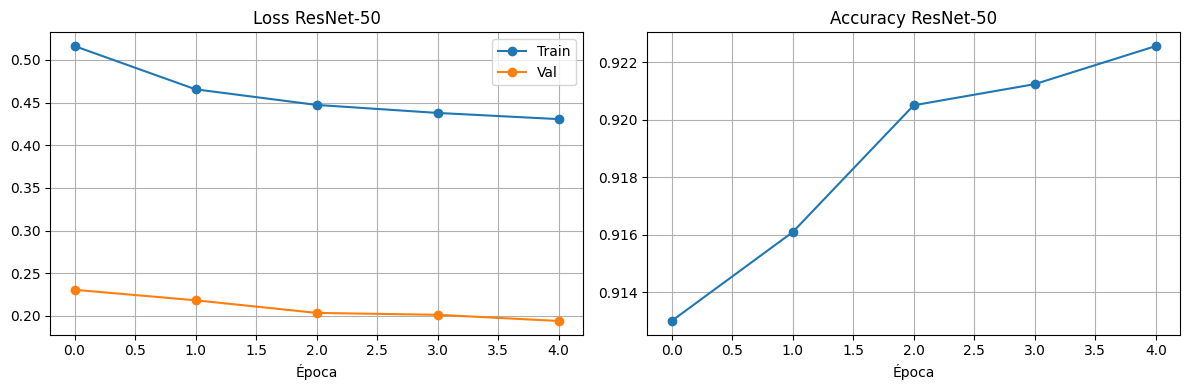

In [ ]:
print("Entrenamiento ResNet-50")

history_resnet = entrenar(
    model_resnet,
    train_loader,
    val_loader,
    optimizer_resnet,
    criterion,
    scheduler_resnet,
    epochs=5,
    nombre="ResNet-50"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_resnet['train_loss'], marker='o', label='Train')
ax1.plot(history_resnet['val_loss'], marker='o', label='Val')

ax1.set_title('Loss ResNet-50')
ax1.set_xlabel('Época')
ax1.legend()
ax1.grid(True)

ax2.plot(history_resnet['val_acc'], marker='o')

ax2.set_title('Accuracy ResNet-50')
ax2.set_xlabel('Época')
ax2.grid(True)

plt.tight_layout()

plt.savefig(
    f'{DRIVE_TFM}/figuras/resnet50_curvas_hito1.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [ ]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memoria GPU liberada")

Memoria GPU liberada


Entrenamiento ViT-LoRA
[ViT-LoRA] Epoch 01/5 | Train 0.5666 | Val 0.3577 | Acc 0.9065 | LR 5.0e-05
[ViT-LoRA] Epoch 02/5 | Train 0.5231 | Val 0.2974 | Acc 0.9117 | LR 5.0e-05
[ViT-LoRA] Epoch 03/5 | Train 0.4957 | Val 0.2470 | Acc 0.9146 | LR 5.0e-05
[ViT-LoRA] Epoch 04/5 | Train 0.4686 | Val 0.2414 | Acc 0.9158 | LR 5.0e-05
[ViT-LoRA] Epoch 05/5 | Train 0.4398 | Val 0.2233 | Acc 0.9174 | LR 5.0e-05


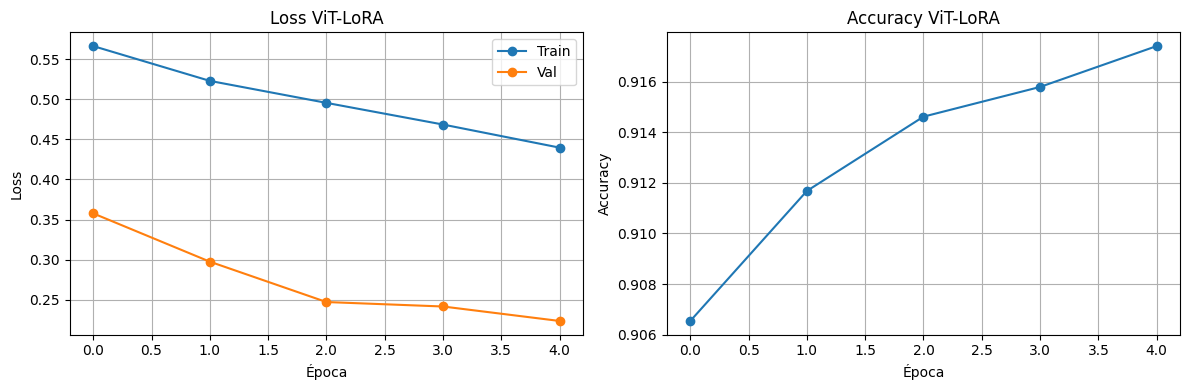

In [ ]:
print("Entrenamiento ViT-LoRA")

history_vit = entrenar(
    model_vit,
    train_loader,
    val_loader,
    optimizer_vit,
    criterion,
    scheduler_vit,
    epochs=5,
    es_vit=True,
    nombre="ViT-LoRA"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_vit['train_loss'], marker='o', label='Train')
ax1.plot(history_vit['val_loss'], marker='o', label='Val')

ax1.set_title('Loss ViT-LoRA')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')

ax1.legend()
ax1.grid(True)

ax2.plot(history_vit['val_acc'], marker='o')

ax2.set_title('Accuracy ViT-LoRA')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')

ax2.grid(True)

plt.tight_layout()

plt.savefig(
    f'{DRIVE_TFM}/figuras/vit_lora_curvas_hito1.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Análisis de las curvas de entrenamiento
ResNet-50

ResNet-50 aprende bastante rápido desde las primeras épocas. El loss de entrenamiento baja de forma estable y la validación mejora hasta la época 4, donde se obtiene el mejor resultado. En la última época el loss de validación sube ligeramente y la accuracy cae un poco, así que probablemente el modelo ya estaba empezando a ajustarse demasiado al conjunto de entrenamiento.

Esto tiene sentido porque en esta configuración el encoder está completamente congelado y solo se entrena la cabeza final. La capacidad de adaptación del modelo es limitada y llega relativamente rápido a un punto donde deja de mejorar.

En general, cinco épocas parecen suficientes para esta primera prueba. Entrenar más tiempo probablemente no aportaría demasiada mejora sin desbloquear parte del encoder.

ViT-LoRA

En ViT-LoRA el aprendizaje inicial es más lento. La primera época queda claramente por debajo de ResNet, pero a partir de la segunda el modelo mejora bastante rápido y termina superándolo tanto en accuracy como en loss de validación.

A diferencia de ResNet, la validación sigue mejorando hasta la última época y no aparece una señal clara de sobreajuste. Da la sensación de que el modelo todavía no había terminado de converger del todo.

Probablemente esto se deba a que LoRA modifica únicamente una parte pequeña del mecanismo de atención y necesita algo más de tiempo para adaptarse a la tarea. Aun así, la evolución entre épocas es bastante estable.

En conjunto, los resultados son suficientes para validar el pipeline del Hito 1 y comparar ambas arquitecturas en condiciones similares. ViT-LoRA parece tener más margen de mejora aumentando el número de épocas, mientras que en ResNet seguramente tendría más sentido empezar a desbloquear capas del encoder antes que seguir entrenando únicamente la cabeza final.

## Evaluación

Una vez entrenados ambos modelos, el siguiente paso es evaluarlos siguiendo el protocolo del challenge IJCB 2025, alineado con la norma ISO/IEC 30107-3 para sistemas PAD.

Además de la accuracy, aquí cobran importancia métricas más específicas del problema. APCER mide cuántos ataques consiguen pasar como documentos legítimos, mientras que BPCER indica cuántos documentos reales son rechazados por error. En sistemas de onboarding normalmente interesa mantener un APCER muy bajo, aunque eso implique asumir cierto aumento de falsos rechazos.

También se calcula el EER (Equal Error Rate), que representa el punto donde APCER y BPCER se igualan. Por último, se utiliza AVRank, que es la métrica oficial del challenge y da más peso al comportamiento del sistema en escenarios de alta seguridad, especialmente en APCER1%.

Además de las métricas globales, también se analiza el APCER por tipo de ataque para comprobar si existen diferencias entre arquitecturas dependiendo del PAI species.


In [ ]:
def evaluar_completo(model, loader, titulo="Evaluación", es_vit=False):

    model.eval()

    all_preds = []
    all_scores = []
    all_labels = []
    all_tipos = []

    with torch.no_grad():

        for imgs, labels, tipos, _ in loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            out = model(pixel_values=imgs).logits if es_vit else model(imgs)

            probs = F.softmax(out, dim=1)[:, 1]
            preds = torch.argmax(out, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_scores.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_tipos.extend(tipos)

    all_preds = np.array(all_preds)
    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)
    all_tipos = np.array(all_tipos)

    ataques = all_labels == 1
    genuinos = all_labels == 0

    acc = np.mean(all_preds == all_labels)

    apcer = np.sum((all_preds == 0) & ataques) / max(np.sum(ataques), 1)

    bpcer = np.sum((all_preds == 1) & genuinos) / max(np.sum(genuinos), 1)

    # Con pos_label=1 (ataque):
    #   fpr = genuinos clasificados como ataque = BPCER
    #   fnr = 1 - tpr = ataques clasificados como genuino = APCER
    fpr, tpr, _ = roc_curve(all_labels, all_scores, pos_label=1)
    fnr = 1 - tpr

    # EER usando det_curve — más estable que brentq+interp1d
    fpr_det, fnr_det, _ = det_curve(all_labels, all_scores, pos_label=1)
    eer_idx = np.argmin(np.abs(fpr_det - fnr_det))
    eer = (fpr_det[eer_idx] + fnr_det[eer_idx]) / 2

    # BPCER@APCER_X%:
    # Buscar el punto donde APCER (fnr) <= target y devolver BPCER (fpr) en ese punto.
    # fnr está en orden descendente porque fpr/tpr de roc_curve van de menor a mayor.
    def bpcer_at_apcer(target):
        # fnr es APCER, va de mayor a menor; fpr es BPCER
        # Buscar el primer índice donde fnr <= target (umbral suficientemente alto)
        indices = np.where(fnr <= target)[0]
        if len(indices) == 0:
            return 1.0  # nunca llega a ese APCER
        idx = indices[0]
        return float(fpr[idx])

    b10 = bpcer_at_apcer(0.10)
    b5  = bpcer_at_apcer(0.05)
    b1  = bpcer_at_apcer(0.01)

    avrank = 0.2 * b10 + 0.3 * b5 + 0.5 * b1

    print(f"\n{titulo}")
    print(f"Accuracy           : {acc:.4f}")
    print(f"APCER              : {apcer:.4f}")
    print(f"BPCER              : {bpcer:.4f}")
    print(f"EER                : {eer:.4f}")
    print(f"BPCER@APCER10%     : {b10:.4f}")
    print(f"BPCER@APCER5%      : {b5:.4f}")
    print(f"BPCER@APCER1%      : {b1:.4f}")
    print(f"AVRank             : {avrank:.4f}")

    print("\nAPCER por tipo de ataque:")

    for tipo in sorted(t for t in np.unique(all_tipos) if t != 'bonafide'):

        mask = all_tipos == tipo

        p_t = all_preds[mask]
        l_t = all_labels[mask]

        if np.sum(l_t == 1) == 0:
            continue

        apcer_t = np.sum((p_t == 0) & (l_t == 1)) / np.sum(l_t == 1)

        print(f"  {tipo:12s}: {apcer_t:.4f}")

    return all_preds, all_scores, all_labels


def plot_confusion(labels, preds, titulo):

    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Genuino', 'Ataque'],
        yticklabels=['Genuino', 'Ataque'],
        ax=ax
    )

    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(titulo)

    plt.tight_layout()

    fig.savefig(
        f'{DRIVE_TFM}/figuras/{titulo}.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()


def plot_det_curve(labels, scores, titulo):

    fpr_det, fnr_det, _ = det_curve(
        labels,
        scores,
        pos_label=1
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(fpr_det * 100, fnr_det * 100, lw=1.5)

    eer_idx = np.argmin(np.abs(fpr_det - fnr_det))

    eer_val = (
        fpr_det[eer_idx] + fnr_det[eer_idx]
    ) / 2 * 100

    ax.scatter(
        fpr_det[eer_idx] * 100,
        fnr_det[eer_idx] * 100,
        label=f'EER={eer_val:.1f}%'
    )

    ax.set_xlabel('BPCER (%)')
    ax.set_ylabel('APCER (%)')
    ax.set_title(f'Curva DET - {titulo}')

    ax.legend()

    plt.tight_layout()

    fig.savefig(
        f'{DRIVE_TFM}/figuras/DET_{titulo}.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

# Evaluación en validación y cross-dataset

Primero se evalúan ambos modelos sobre el conjunto de validación de ID Cards. Después se realiza una evaluación cross-dataset utilizando SYN PASS como test externo para comprobar capacidad de generalización fuera de dominio.


VALIDACIÓN ID CARDS - RESNET50

ResNet50 Val
Accuracy           : 0.9226
APCER              : 0.0155
BPCER              : 0.7268
EER                : 0.1720
BPCER@APCER10%     : 0.3035
BPCER@APCER5%      : 0.4823
BPCER@APCER1%      : 0.8094
AVRank             : 0.6101

APCER por tipo de ataque:
  composite   : 0.0865
  print       : 0.0061
  screen      : 0.0094


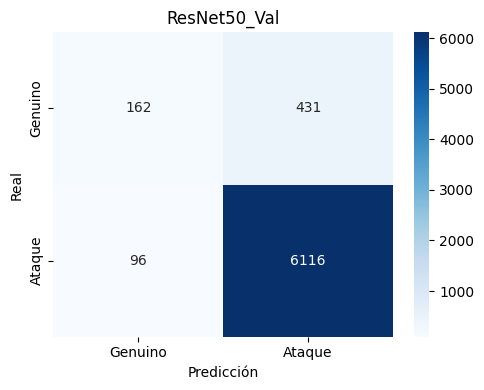

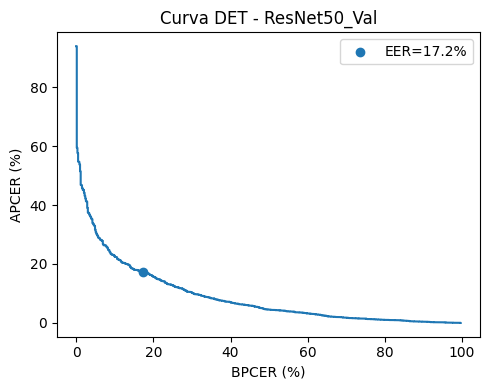


VALIDACIÓN ID CARDS - ViT-LoRA

ViT-LoRA Val
Accuracy           : 0.9174
APCER              : 0.0190
BPCER              : 0.7487
EER                : 0.1804
BPCER@APCER10%     : 0.3626
BPCER@APCER5%      : 0.5801
BPCER@APCER1%      : 0.8297
AVRank             : 0.6614

APCER por tipo de ataque:
  composite   : 0.0734
  print       : 0.0163
  screen      : 0.0094


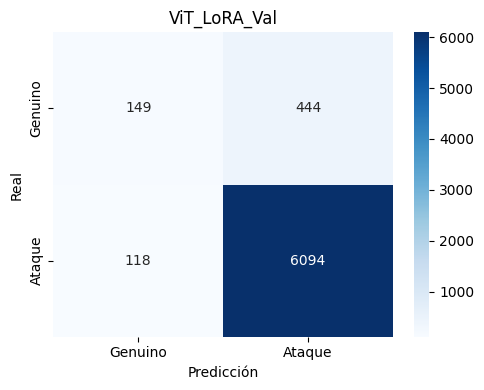

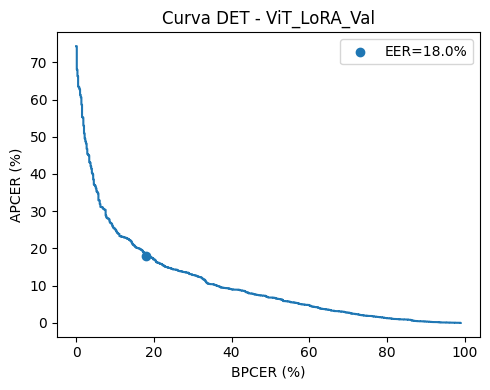


CROSS-DATASET SYN PASS

ResNet50 SYN PASS
Accuracy           : 0.6678
APCER              : 0.0000
BPCER              : 0.9974
EER                : 0.4398
BPCER@APCER10%     : 0.8135
BPCER@APCER5%      : 0.8719
BPCER@APCER1%      : 0.9353
AVRank             : 0.8919

APCER por tipo de ataque:
  printed     : 0.0000
  screen      : 0.0000

ViT-LoRA SYN PASS
Accuracy           : 0.6669
APCER              : 0.0000
BPCER              : 1.0000
EER                : 0.5498
BPCER@APCER10%     : 0.8696
BPCER@APCER5%      : 0.9117
BPCER@APCER1%      : 0.9767
AVRank             : 0.9358

APCER por tipo de ataque:
  printed     : 0.0000
  screen      : 0.0000


In [ ]:
print("\nVALIDACIÓN ID CARDS - RESNET50")

preds_val_r, scores_val_r, labels_val_r = evaluar_completo(
    model_resnet,
    val_loader,
    titulo="ResNet50 Val"
)

plot_confusion(labels_val_r, preds_val_r, "ResNet50_Val")
plot_det_curve(labels_val_r, scores_val_r, "ResNet50_Val")


print("\nVALIDACIÓN ID CARDS - ViT-LoRA")

preds_val_v, scores_val_v, labels_val_v = evaluar_completo(
    model_vit,
    val_loader,
    titulo="ViT-LoRA Val",
    es_vit=True
)

plot_confusion(labels_val_v, preds_val_v, "ViT_LoRA_Val")
plot_det_curve(labels_val_v, scores_val_v, "ViT_LoRA_Val")


print("\nCROSS-DATASET SYN PASS")

preds_syn_r, scores_syn_r, labels_syn_r = evaluar_completo(
    model_resnet,
    test_loader,
    titulo="ResNet50 SYN PASS"
)

preds_syn_v, scores_syn_v, labels_syn_v = evaluar_completo(
    model_vit,
    test_loader,
    titulo="ViT-LoRA SYN PASS",
    es_vit=True
)

# Ablación de segmentación

Además de evaluar los modelos sobre las imágenes segmentadas con SAM, también quise comprobar hasta qué punto la segmentación estaba influyendo realmente en el rendimiento final.

Para eso comparo tres escenarios distintos:

- documentos segmentados con SAM,
- segmentación clásica basada en OpenCV,
- e imagen completa sin segmentar.

La idea aquí era ver si el modelo se beneficia realmente de centrarse únicamente en el documento o si parte del contexto exterior también aporta información útil para detectar ataques.

Para la versión OpenCV utilizo una segmentación sencilla basada en bordes y contornos. No busca ser perfecta, simplemente generar una referencia clásica para compararla con SAM.

In [ ]:
def segmentar_opencv(img_pil, margen=0.08):

    img_np = np.array(img_pil)
    # Conversión a escala de grises
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Detección básica de bordes
    edges = cv2.Canny(
        cv2.GaussianBlur(gray, (5, 5), 0),
        50,
        150
    )

    # Dilatar para unir regiones
    dilated = cv2.dilate(
        edges,
        cv2.getStructuringElement(cv2.MORPH_RECT, (10, 10)),
        iterations=2
    )

    contours, _ = cv2.findContours(
        dilated,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    W, H = img_pil.size

    # Fallback simple si no aparece ningún contorno
    mx = int(W * margen)
    my = int(H * margen)

    if not contours:

        return img_pil.crop((
            mx,
            my,
            W - mx,
            H - my
        ))

    # Seleccionar el contorno más grande
    x, y, w_c, h_c = cv2.boundingRect(
        max(contours, key=cv2.contourArea)
    )

    ratio = (w_c * h_c) / (W * H)

    # Evitar recortes absurdos
    if ratio < 0.05 or ratio > 0.90:

        return img_pil.crop((
            mx,
            my,
            W - mx,
            H - my
        ))

    pad = int(min(W, H) * margen)

    return img_pil.crop((
        max(0, x - pad),
        max(0, y - pad),
        min(W, x + w_c + pad),
        min(H, y + h_c + pad)
    ))


class AblationDataset(Dataset):

    def __init__(self, df, mode='sam', transform=None):

        self.df = df.reset_index(drop=True)

        self.mode = mode
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        fila = self.df.iloc[idx]

        label = int(fila['etiqueta_binaria'])
        tipo = fila['tipo']

        try:

            # Imagen segmentada con SAM
            if self.mode == 'sam':

                image = Image.open(
                    fila['ruta']
                ).convert('RGB')

            # Segmentación clásica OpenCV
            elif self.mode == 'opencv':

                image = segmentar_opencv(
                    Image.open(
                        fila['ruta_original']
                    ).convert('RGB')
                )

            # Imagen completa
            else:

                image = Image.open(
                    fila['ruta_original']
                ).convert('RGB')

        except Exception:

            image = Image.new(
                'RGB',
                (IMG_SIZE, IMG_SIZE),
                color=(0, 0, 0)
            )

        if self.transform:
            image = self.transform(image)

        return image, label, tipo, fila['ruta']

# Evaluación de la ablación de segmentación

Para analizar cuánto aporta realmente la segmentación al problema PAD, se comparan tres variantes distintas sobre el mismo conjunto de validación: documentos segmentados con SAM, segmentación clásica mediante OpenCV e imágenes completas sin segmentar.

La idea aquí no es solo comparar métricas, sino comprobar si el modelo depende realmente de aislar el documento o si parte del contexto exterior también aporta información útil para detectar ataques.

Los resultados de cada combinación se guardan posteriormente en disco para poder reutilizarlos más adelante sin repetir inferencias.

In [ ]:
print("ABLACIÓN DE SEGMENTACIÓN")

os.makedirs(f'{DRIVE_TFM}/resultados', exist_ok=True)

resultados_ablacion = {}

configs_modelos = [
    ('ResNet-50', model_resnet, False),
    ('ViT-LoRA', model_vit, True)
]

for modo in ('sam', 'opencv', 'full'):
    # Construir dataset según el tipo de segmentación
    dataset = AblationDataset(
        val_idcards,
        mode=modo,
        transform=transform_val
    )
    # Loader compartido para evaluación
    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        collate_fn=collate_fn
    )

    print(f"\nModo evaluado: {modo.upper()}")

    for nombre_modelo, modelo, es_vit in configs_modelos:

        # Ejecutar evaluación completa
        preds, scores, labels = evaluar_completo(
            modelo,
            loader,
            titulo=f"{nombre_modelo} [{modo}]",
            es_vit=es_vit
        )

        # Guardar resultados para análisis posterior
        resultados_ablacion[f'{nombre_modelo}_{modo}'] = {
            'preds': preds.tolist(),
            'scores': scores.tolist(),
            'labels': labels.tolist()
        }

# Exportar resultados finales
with open(
    f'{DRIVE_TFM}/resultados/ablacion_hito1.json',
    'w'
) as f:

    json.dump(resultados_ablacion, f)

print("\nResultados de ablación guardados")

ABLACIÓN DE SEGMENTACIÓN

Modo evaluado: SAM

ResNet-50 [sam]
Accuracy           : 0.9226
APCER              : 0.0155
BPCER              : 0.7268
EER                : 0.1720
BPCER@APCER10%     : 0.3035
BPCER@APCER5%      : 0.4823
BPCER@APCER1%      : 0.8094
AVRank             : 0.6101

APCER por tipo de ataque:
  composite   : 0.0865
  print       : 0.0061
  screen      : 0.0094

ViT-LoRA [sam]
Accuracy           : 0.9174
APCER              : 0.0190
BPCER              : 0.7487
EER                : 0.1804
BPCER@APCER10%     : 0.3626
BPCER@APCER5%      : 0.5801
BPCER@APCER1%      : 0.8297
AVRank             : 0.6614

APCER por tipo de ataque:
  composite   : 0.0734
  print       : 0.0163
  screen      : 0.0094

Modo evaluado: OPENCV

ResNet-50 [opencv]
Accuracy           : 0.9217
APCER              : 0.0283
BPCER              : 0.6020
EER                : 0.1467
BPCER@APCER10%     : 0.2698
BPCER@APCER5%      : 0.4435
BPCER@APCER1%      : 0.7909
AVRank             : 0.5825

APCER por tipo

# Guardado de modelos y predicciones

Una vez finalizado el entrenamiento, se guardan tanto los checkpoints de los modelos como las predicciones generadas sobre validación y test. Esto permite reutilizar resultados más adelante sin necesidad de repetir todo el proceso de inferencia, algo especialmente útil para análisis posteriores, comparación de métricas o generación de gráficas adicionales.

En los checkpoints se almacena el estado completo del modelo, el optimizador y el historial de entrenamiento. En el caso de ViT-LoRA también se guarda la configuración LoRA utilizada durante el fine-tuning.

Además, se exportan las probabilidades y etiquetas reales de cada conjunto para poder recalcular métricas posteriormente sin volver a ejecutar los modelos.

In [ ]:
os.makedirs(f'{DRIVE_TFM}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_TFM}/resultados', exist_ok=True)

# ResNet-50: guardado estándar
torch.save(
    {
        'model_state_dict': model_resnet.state_dict(),
        'optimizer_state_dict': optimizer_resnet.state_dict(),
        'history': history_resnet,
        'epoch': len(history_resnet['train_loss'])
    },
    f'{DRIVE_TFM}/checkpoints/resnet50_hito1.pth'
)
print('Checkpoint guardado: resnet50_hito1.pth')

# ViT-LoRA: save_pretrained guarda solo los pesos LoRA + config
# Permite recargar con PeftModel.from_pretrained(base_model, path)
vit_lora_path = f'{DRIVE_TFM}/checkpoints/vit_lora_hito1'
model_vit.save_pretrained(vit_lora_path)

# Guardar también optimizer e historial por separado
torch.save(
    {
        'optimizer_state_dict': optimizer_vit.state_dict(),
        'history': history_vit,
        'epoch': len(history_vit['train_loss'])
    },
    f'{vit_lora_path}/training_state.pth'
)
print('Checkpoint guardado: vit_lora_hito1/')


def guardar_predicciones(model, loader, nombre, es_vit=False):

    model.eval()

    scores = []
    labels_all = []

    with torch.no_grad():

        for imgs, labels, _, _ in loader:

            imgs = imgs.to(device)

            out = (
                model(pixel_values=imgs).logits
                if es_vit
                else model(imgs)
            )

            probs = F.softmax(out, dim=1)[:, 1]

            scores.extend(probs.cpu().numpy())
            labels_all.extend(labels.numpy())

    np.save(
        f'{DRIVE_TFM}/resultados/{nombre}_scores.npy',
        np.array(scores)
    )

    np.save(
        f'{DRIVE_TFM}/resultados/{nombre}_labels.npy',
        np.array(labels_all)
    )

    print(f'Predicciones guardadas: {nombre}')


configs_pred = [

    (model_resnet, val_loader, 'resnet_val', False),
    (model_vit, val_loader, 'vit_val', True),

    (model_resnet, test_loader, 'resnet_test_synpass', False),
    (model_vit, test_loader, 'vit_test_synpass', True)
]

for model, loader, nombre, es_vit in configs_pred:

    guardar_predicciones(
        model,
        loader,
        nombre,
        es_vit
    )

Checkpoint guardado: resnet50_hito1.pth
Checkpoint guardado: vit_lora_hito1/
Predicciones guardadas: resnet_val
Predicciones guardadas: vit_val
Predicciones guardadas: resnet_test_synpass
Predicciones guardadas: vit_test_synpass


In [ ]:
#guardar metadatos
notebook_name = "Hito_1_Lara_Polanco_Avanzado.ipynb"
notebook_path = os.path.join('/content/drive/MyDrive/Colab Notebooks', notebook_name)

try:
    with open(notebook_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    # Eliminar widgets corruptos
    if "widgets" in nb.get("metadata", {}):
        del nb["metadata"]["widgets"]

    with open(notebook_path, "w", encoding="utf-8") as f:
        json.dump(nb, f)

    print("Notebook limpiado correctamente.")
except FileNotFoundError:
    print(f"no se encontró el notebook '{notebook_path}'.")
except Exception as e:
    print(f"error: {e}")

Notebook limpiado correctamente.


In [ ]:
input_path = "/content/drive/MyDrive/Colab Notebooks/Hito_1_Lara_Polanco_Avanzado.ipynb"
output_path = "/content/Hito_1_Lara_Polanco_LIMPIO.ipynb"

with open(input_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Eliminar metadata problemática
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

# Limpiar metadata de celdas
for cell in nb.get("cells", []):
    if "metadata" in cell:
        cell["metadata"] = {}

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(nb, f)

print("Notebook limpio guardado en:")
print(output_path)

Notebook limpio guardado en:
/content/Hito_1_Lara_Polanco_LIMPIO.ipynb


In [ ]:
# Ejecutar primero como check para hito 2
print(len(df_idcards), len(df_synpass))
print(df_idcards.columns.tolist())

17424 9141
['ruta', 'tipo', 'etiqueta_binaria', 'document_id']


## Cross-domain: mezclando ID Cards y SYN PASS en entrenamiento

Hasta ahora el modelo solo ha visto ID Cards durante el entrenamiento. Eso funciona, pero tiene un problema: el modelo puede estar aprendiendo cosas del entorno de captura (el fondo, la iluminación, la resolución típica de ese dataset) en lugar de aprender a detectar si un documento es real o un ataque. Cuando después lo evaluamos con SYN PASS, ese sesgo se nota.

La idea aquí es meter una fracción de SYN PASS también en entrenamiento. No toda, porque queremos seguir usándola como test externo, sino suficiente para que el modelo vea dos dominios distintos y no se "acostumbre" a uno solo. Esto actúa como una forma de regularización implícita y es uno de los argumentos más fáciles de defender en el paper.

### Un problema que hay que resolver antes de mezclar

El document_id que usamos para evitar data leakage se construye como archivo.split('_')[0], es decir, el primer trozo del nombre del archivo. Eso funciona bien dentro de cada dataset por separado, pero al mezclarlos aparece un riesgo: un archivo de ID Cards puede empezar por "001" y un archivo de SYN PASS también. Si eso ocurre, el sistema los trataría como el mismo documento y podríamos acabar con imágenes del mismo "documento" en train y en validación sin darnos cuenta.

Para evitarlo, simplemente añadimos un prefijo al ID según el dataset de origen: "idc_" para ID Cards y "syn_" para SYN PASS. Así los espacios de nombres quedan completamente separados y la verificación de leakage puede hacerse de forma limpia.

In [ ]:
def construir_dataset_cross_domain(
    df_idc,
    df_syn,
    syn_train_ratio=0.30,   # qué fracción de documentos de SYN PASS entra en train
    val_size=0.20,
    seed=42
):
    """
    Mezcla ID Cards y SYN PASS en un único DataFrame listo para entrenar.

    La idea es sencilla: ID Cards se parte en train/val como siempre,
    y de SYN PASS cogemos solo una fracción pequeña para train (por defecto
    el 30% de sus documentos). El resto de SYN PASS se queda como test
    externo puro, que es lo que usaremos para medir generalización real.

    La partición siempre se hace a nivel de documento, nunca de imagen,
    para evitar que capturas del mismo documento acaben en splits distintos.
    La columna 'source' nos dice de dónde viene cada imagen, útil luego
    para desagregar métricas por dataset.
    """
    rng = np.random.default_rng(seed)

    # Antes de nada, prefijamos los document_id con el dataset de origen.
    # Sin esto, un archivo "001_front.jpg" de ID Cards y otro de SYN PASS
    # tendrían el mismo document_id y podríamos mezclarlos sin darnos cuenta.
    df_idc = df_idc.copy()
    df_syn = df_syn.copy()
    df_idc['document_id'] = 'idc_' + df_idc['document_id'].astype(str)
    df_syn['document_id']  = 'syn_' + df_syn['document_id'].astype(str)
    df_idc['source'] = 'idcards'
    df_syn['source']  = 'synpass'

    # Partición de ID Cards: 80% train, 20% val, siempre por documento
    gss_idc = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
    train_idx_idc, val_idx_idc = next(
        gss_idc.split(df_idc, groups=df_idc['document_id'])
    )
    df_idc['split'] = 'unassigned'
    df_idc.iloc[train_idx_idc, df_idc.columns.get_loc('split')] = 'train'
    df_idc.iloc[val_idx_idc,   df_idc.columns.get_loc('split')] = 'val'

    # De SYN PASS, seleccionamos aleatoriamente un subconjunto de documentos
    # para train. El resto se reserva íntegro como test externo.
    docs_syn = df_syn['document_id'].unique()
    n_train_syn = max(1, int(len(docs_syn) * syn_train_ratio))
    docs_train_syn = rng.choice(docs_syn, size=n_train_syn, replace=False)
    df_syn['split'] = 'test_syn'
    df_syn.loc[df_syn['document_id'].isin(docs_train_syn), 'split'] = 'train'

    # Comprobación de seguridad: ningún documento puede aparecer en dos splits.
    # Si algún assert falla aquí hay un bug en la partición, no en los datos.
    docs_train = set(df_idc[df_idc['split']=='train']['document_id']) | \
                 set(df_syn[df_syn['split']=='train']['document_id'])
    docs_val   = set(df_idc[df_idc['split']=='val']['document_id'])
    docs_test  = set(df_syn[df_syn['split']=='test_syn']['document_id'])

    assert len(docs_train & docs_val)  == 0, "LEAKAGE: document_ids comunes train/val"
    assert len(docs_train & docs_test) == 0, "LEAKAGE: document_ids comunes train/test"
    assert len(docs_val   & docs_test) == 0, "LEAKAGE: document_ids comunes val/test"
    print(" Verificación de data leakage: sin solapamiento entre splits")

    # Juntamos todo y mostramos cómo quedó repartido para poder revisarlo
    df_all = pd.concat([df_idc, df_syn], ignore_index=True)

    for split in ['train', 'val', 'test_syn']:
        sub = df_all[df_all['split'] == split]
        n_bon = (sub['etiqueta_binaria'] == 0).sum()
        n_atk = (sub['etiqueta_binaria'] == 1).sum()
        print(f"  {split:9s}: {len(sub):6d} imágenes  "
              f"| Genuinos: {n_bon}  Ataques: {n_atk}  "
              f"| Fuentes: {sub['source'].value_counts().to_dict()}")

    return df_all


df_cross = construir_dataset_cross_domain(df_idcards, df_synpass)

train_cross = df_cross[df_cross['split'] == 'train'].reset_index(drop=True)
val_cross   = df_cross[df_cross['split'] == 'val'].reset_index(drop=True)
test_syn    = df_cross[df_cross['split'] == 'test_syn'].reset_index(drop=True)

 Verificación de data leakage: sin solapamiento entre splits
  train    :  13374 imágenes  | Genuinos: 3340  Ataques: 10034  | Fuentes: {'idcards': 10619, 'synpass': 2755}
  val      :   6805 imágenes  | Genuinos: 593  Ataques: 6212  | Fuentes: {'idcards': 6805}
  test_syn :   6386 imágenes  | Genuinos: 2112  Ataques: 4274  | Fuentes: {'synpass': 6386}


## Aumentación agresiva con Albumentations

Con alrededor de 17.000 imágenes el dataset no es enorme, y eso se nota especialmente cuando entrenamos arquitecturas tan grandes como DINOv2 o CLIP, que tienen muchísimos más parámetros de los que el dataset por sí solo puede calibrar bien. La aumentación agresiva es la forma más directa de compensarlo sin recoger más datos: en lugar de ver siempre la misma imagen, el modelo ve cada época una versión ligeramente diferente, lo que dificulta el sobreajuste y mejora la capacidad de generalización a dominios nuevos.

Ahora bien, en PAD no vale cualquier tipo de aumentación. La señal que delata un ataque suele estar precisamente en la textura: la trama de puntos de una impresora, el patrón de moiré de una pantalla, el acabado plástico de una laminación. Transformaciones geométricas agresivas como ElasticTransform o GridDistortion distorsionan esa microestructura de formas que no ocurren en escenarios reales de onboarding, y el riesgo es que el modelo acabe confundiendo artefactos de la propia aumentación con artefactos de ataque. Es un error sutil pero que se nota en las métricas.

Por eso todas las transformaciones elegidas aquí actúan sobre la fotometría y la compresión, no sobre la geometría del documento. La compresión JPEG simula imágenes que han pasado por varios ciclos de recompresión, algo habitual cuando el atacante fotografía una pantalla o imprime y vuelve a fotografiar. El blur y el ruido ISO replican condiciones de captura malas: poca luz, movimiento, sensor de gama baja. El RGBShift aproxima los cambios de temperatura de color que introduce la pantalla o el foco del capturador, de forma más fiel que HueSaturationValue, que altera el tono de una manera que no corresponde a ningún fenómeno físico real. La rotación está limitada a +-15° porque más que eso ya no es realista en un flujo de onboarding, y el flip horizontal tiene una probabilidad baja precisamente porque muchos documentos tienen texto o logos que no tienen sentido espejados.

In [ ]:
IMG_SIZE = 224  # mismo tamaño que en el Hito 1, para que los checkpoints sean comparables

# Lo que ve el modelo durante el entrenamiento: una versión degradada y ruidosa
# de cada imagen, distinta en cada época. La idea es que si aprende a clasificar
# bien incluso con imágenes malas, generalizará mejor con imágenes reales.
transform_train_albu = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    # Una foto de pantalla suele haber pasado por varios ciclos de compresión
    # antes de llegar al sistema. Calidad entre 20 y 80 cubre desde WhatsApp
    # hasta una captura decente con el móvil.
    A.ImageCompression(quality_lower=20, quality_upper=80, p=0.60),

    # El modelo tiene que ser robusto a capturas movidas o documentos impresos
    # ligeramente fuera de foco. Elegimos uno de los tres aleatoriamente
    # para no sesgarnos hacia un tipo de blur concreto.
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.MotionBlur(blur_limit=7, p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
    ], p=0.55),

    # Capturar en poca luz introduce ruido de crominancia característico
    # de los sensores de móvil. ISONoise lo replica de forma bastante realista.
    A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.45),

    # El balance de blancos cambia según si el capturador usa luz de día,
    # fluorescente o pantalla. RGBShift lo aproxima bien; preferimos esto
    # a HueSaturationValue porque no altera el tono del documento, solo
    # su temperatura percibida.
    A.RGBShift(
        r_shift_limit=20,
        g_shift_limit=15,
        b_shift_limit=25,
        p=0.50
    ),

    # Algunos documentos llegan escaneados en grises o directamente
    # son fotocopias. Con p=0.20 es poco frecuente pero el modelo lo ve.
    A.ToGray(p=0.20),

    # Variaciones normales de exposición según el entorno de captura.
    # Los valores son moderados para no destruir el color del documento.
    A.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.15,
        hue=0.08,
        p=0.50
    ),

    # Nadie sujeta el documento perfectamente recto. Limitamos a +-15°
    # porque más que eso ya no es realista en un flujo de onboarding,
    # y rotaciones grandes recortan las esquinas del documento.
    A.Rotate(limit=15, border_mode=0, p=0.50),

    # Solo un 20% de probabilidad porque muchos documentos tienen
    # texto o logos que no tienen sentido espejados.
    A.HorizontalFlip(p=0.20),

    # Media y std de ImageNet: obligatorio para no desestabilizar
    # los pesos preentrenados de DINOv2, CLIP y ViT.
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# En validación y test no tocamos nada: solo resize y normalización.
# Cualquier otra cosa contaminaría la evaluación.
transform_val_albu = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

print("Pipelines de Albumentations configurados")
print(f"  Train: {len(transform_train_albu)} transformaciones | Val/Test: solo normalización")

Pipelines de Albumentations configurados
  Train: 11 transformaciones | Val/Test: solo normalización


/tmp/ipykernel_11152/2315834699.py:12: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=20, quality_upper=80, p=0.60),


## Dataset y DataLoaders

En el Hito 1 teníamos una clase Dataset pensada para torchvision. Albumentations
espera recibir un array de NumPy en lugar de un objeto PIL, así que necesitamos
una versión nueva. Aprovechamos para unificar también la interfaz de todos los
modelos: ViT-LoRA, DINOv2 y CLIP van a usar exactamente la misma clase, lo que
facilita comparar resultados sin que las diferencias vengan del pipeline de datos.

El otro problema que resolvemos aquí es el desbalance de clases. En el dataset
mezclado hay bastantes más ataques que genuinos, y si entrenamos así el modelo
aprende rápido a predecir siempre ataque y consigue una accuracy razonable sin
haber aprendido nada útil. En lugar de duplicar imágenes o recortar el conjunto
mayoritario, usamos un sampler ponderado que ajusta la probabilidad de muestreo
de cada imagen. El resultado es un batch efectivo más equilibrado sin modificar
los datos.

Para la A100 subimos el batch a 128 en train y 256 en validación, que con 40 GB de memoria es perfectamente manejable para estas arquitecturas.

In [ ]:
class PADDatasetAlbu(Dataset):
    """
    Versión del Dataset compatible con Albumentations, que trabaja con arrays
    NumPy en lugar de imágenes PIL. Funciona igual para ViT-LoRA, DINOv2 y CLIP,
    y acepta tanto rutas SAM como imágenes originales según lo que indique use_col.
    Si una imagen no se puede abrir, devuelve un array negro del tamaño correcto
    para no romper el entrenamiento por un archivo corrupto.
    """
    def __init__(self, df, transform=None, use_col='ruta'):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.use_col   = use_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila   = self.df.iloc[idx]
        label  = int(fila['etiqueta_binaria'])
        tipo   = fila.get('tipo', 'unknown')
        source = fila.get('source', 'unknown')

        try:
            img_np = np.array(Image.open(fila[self.use_col]).convert('RGB'))
        except Exception:
            img_np = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

        if self.transform:
            img_tensor = self.transform(image=img_np)['image']
        else:
            img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.

        return img_tensor, label, tipo, source


def collate_pad(batch):
    # Devolvemos también tipo y source para poder desagregar métricas
    # por PAI species y por dataset de origen sin tener que relanzar inferencia
    imgs    = torch.stack([b[0] for b in batch])
    labels  = torch.tensor([b[1] for b in batch], dtype=torch.long)
    tipos   = [b[2] for b in batch]
    sources = [b[3] for b in batch]
    return imgs, labels, tipos, sources


def make_balanced_sampler(df):
    """
    Asigna a cada imagen un peso inversamente proporcional a la frecuencia
    de su clase. Así el modelo ve genuinos y ataques con una frecuencia
    parecida durante el entrenamiento, sin duplicar imágenes ni recortar datos.
    """
    labels  = df['etiqueta_binaria'].values
    counts  = np.bincount(labels)
    weights = 1.0 / counts[labels]
    return WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )


# Batch de 128 para train y 256 para val/test. Con 40 GB de la A100
# hay margen de sobra; si hay OOM bajar BATCH_TRAIN a 64 primero.
BATCH_TRAIN = 128
BATCH_VAL   = 256
NUM_WORKERS = 4

sampler_train = make_balanced_sampler(train_cross)

loader_train_cross = DataLoader(
    PADDatasetAlbu(train_cross, transform=transform_train_albu),
    batch_size=BATCH_TRAIN,
    sampler=sampler_train,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,   # evita reiniciar workers entre épocas
    prefetch_factor=2,         # A100 tiene buen ancho de banda, con 2 es suficiente
    collate_fn=collate_pad,
    drop_last=True,
)

loader_val_cross = DataLoader(
    PADDatasetAlbu(val_cross, transform=transform_val_albu),
    batch_size=BATCH_VAL,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    collate_fn=collate_pad,
)

loader_test_syn = DataLoader(
    PADDatasetAlbu(test_syn, transform=transform_val_albu),
    batch_size=BATCH_VAL,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    collate_fn=collate_pad,
)

print(f"DataLoaders listos")
print(f"  Train : {len(loader_train_cross)} batches")
print(f"  Val   : {len(loader_val_cross)} batches")
print(f"  Test  : {len(loader_test_syn)} batches")

DataLoaders listos
  Train : 104 batches
  Val   : 27 batches
  Test  : 25 batches


## DINOv2 como extractor de textura

DINOv2 (Oquab et al., 2024) es un Vision Transformer entrenado con supervisión
propia sobre 142 millones de imágenes naturales. Lo que lo hace interesante para
PAD no es solo su tamaño, sino cómo aprende: al no tener etiquetas, el modelo
se ve obligado a encontrar estructura en las imágenes por sí solo, y lo que
acaba aprendiendo son descriptores muy sensibles a la textura local a nivel de
parche. Eso es exactamente lo que necesitamos aquí, porque la trama de puntos
de una impresora, el patrón de moiré de una pantalla o el acabado plástico de
una laminación son señales de textura, no de forma.

La estrategia es congelar el backbone completo y entrenar solo una cabeza de
clasificación pequeña encima del token [CLS], que es el que resume la imagen
entera. Descongelamos únicamente la capa de normalización final para que el
modelo pueda ajustar ligeramente la escala de las features sin modificar los
pesos que tardó semanas en aprender. Esto tiene dos ventajas: entrena muy
rápido y el riesgo de sobreajuste es mínimo porque los parámetros entrenables
son una fracción pequeña del total.

In [ ]:
class DINOv2PAD(nn.Module):
    """
    DINOv2-base con una cabeza de clasificación binaria encima del token [CLS].
    El backbone se congela casi por completo: solo la layer norm final queda
    libre para que las features puedan ajustarse ligeramente a nuestro dominio
    sin perder lo que el modelo aprendió durante el preentrenamiento.
    """
    def __init__(self, num_classes=2, freeze_backbone=True):
        super().__init__()

        # Cargamos DINOv2-base con pesos oficiales de Meta a través de timm.
        # num_classes=0 elimina la cabeza original y nos da las features brutas.
        self.backbone = timm.create_model(
            'vit_base_patch14_dinov2.lvd142m',
            pretrained=True,
            num_classes=0,
            img_size=224 #interpolar position embeddings a 224 para compatibilidad con el pipeline
        )
        hidden_dim = self.backbone.num_features  # 768 en la variante base

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            # Dejamos libre solo la norma final para que las features
            # puedan escalar un poco hacia nuestro dominio sin reentrenar
            # el transformer entero.
            for param in self.backbone.norm.parameters():
                param.requires_grad = True

        # Cabeza pequeña con dos capas y dropout entre medias.
        # GELU en lugar de ReLU porque es lo que usan los transformers
        # modernos internamente y empíricamente va algo mejor aquí.
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, pixel_values):
        features = self.backbone(pixel_values)
        return self.head(features)


model_dino = DINOv2PAD(freeze_backbone=True).to(device)

n_train = sum(p.numel() for p in model_dino.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_dino.parameters())
print(f"DINOv2 cargado")
print(f"  Parámetros entrenables: {n_train:,} de {n_total:,} "
      f"({100 * n_train / n_total:.2f}%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

DINOv2 cargado
  Parámetros entrenables: 200,450 de 85,923,842 (0.23%)


## CLIP como clasificador con semántica visual-textual

CLIP (Radford et al., 2021) aprendió a alinear imágenes con descripciones
textuales usando 400 millones de pares imagen-texto de internet. Lo que hace
esto diferente para PAD es que su espacio de representación no es puramente
visual: el modelo ha aprendido conceptos como "foto de una pantalla" o
"documento impreso en papel" porque esas descripciones aparecen de forma
natural en los textos con los que fue entrenado. En teoría, eso le da una
ventaja sobre DINOv2 en escenarios donde la distinción entre genuino y ataque
tiene una dimensión semántica, no solo textural.

En la práctica, solo usamos el encoder visual. El encoder de texto no entra
en juego durante el entrenamiento ni en inferencia; simplemente lo descartamos
y ponemos una cabeza de clasificación encima de las features visuales. Lo que
nos interesa medir es si ese preentrenamiento multimodal deja en el encoder
visual algo útil que el preentrenamiento puramente visual de DINOv2 no tiene.

La estrategia de congelación es ligeramente diferente a la de DINOv2: aquí
descongelamos el último bloque del transformer en lugar de solo la norma final.
CLIP fue entrenado con una normalización diferente a ImageNet, así que le damos
un poco más de libertad para que las features se adapten a nuestro pipeline
sin tener que reentrenar el modelo entero.

In [ ]:
class CLIPPAD(nn.Module):
    """
    Encoder visual de CLIP con cabeza de clasificación binaria.
    El encoder de texto no se usa en ningún momento: solo nos interesa
    lo que el preentrenamiento multimodal dejó en la rama visual.
    Descongelamos el último bloque del transformer para que el modelo
    pueda adaptarse al dominio sin perder sus representaciones generales.
    """
    def __init__(self, num_classes=2, freeze_backbone=True):
        super().__init__()

        # Cargamos solo el modelo, ignoramos las transformaciones de CLIP
        # porque ya tenemos nuestro propio pipeline de Albumentations.
        clip_model, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai'
        )
        self.visual = clip_model.visual
        hidden_dim  = self.visual.output_dim  # 512 en ViT-B/32

        if freeze_backbone:
            for param in self.visual.parameters():
                param.requires_grad = False
            # Descongelamos el último bloque del transformer, no solo la norma,
            # porque CLIP usa normalización propia y necesita algo más de margen
            # para adaptarse a nuestro pipeline de ImageNet.
            last_block = list(self.visual.transformer.resblocks.children())[-1]
            for param in last_block.parameters():
                param.requires_grad = True

        # Misma arquitectura de cabeza que DINOv2 para que la comparación
        # entre modelos no se vea afectada por diferencias en el clasificador.
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, pixel_values):
        # CLIP fue entrenado con normalización en [-1, 1] pero usamos ImageNet.
        # Las features siguen siendo válidas; solo cambia la escala de los pesos
        # de entrada, que el último bloque descongelado puede compensar.
        features = self.visual(pixel_values)
        if isinstance(features, tuple):
            features = features[0]
        return self.head(features.float())


model_clip = CLIPPAD(freeze_backbone=True).to(device)

n_train = sum(p.numel() for p in model_clip.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_clip.parameters())
print(f"CLIP cargado")
print(f"  Parámetros entrenables: {n_train:,} de {n_total:,} "
      f"({100 * n_train / n_total:.2f}%)")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP cargado
  Parámetros entrenables: 7,220,738 de 87,982,082 (8.21%)


## Bucle de entrenamiento

Antes de escribir el bucle tuve que tomar unas cuantas decisiones que no
son inmediatas y que afectan bastante al resultado final, así que las
explico aquí para que quede claro el razonamiento.

Lo primero es la precisión mixta. Entrenar en fp16 en lugar de fp32 reduce
el consumo de memoria a la mitad, lo que en la práctica significa que puedo
meter el doble de imágenes por batch sin quedarme sin memoria. El único
riesgo real es que los gradientes sean tan pequeños en fp16 que se redondeen
a cero, y para eso está el GradScaler, que escala los gradientes antes de
que eso ocurra y los devuelve a su rango normal antes del paso del optimizador.

Lo segundo es la acumulación de gradientes. En lugar de actualizar los pesos
con cada batch, acumulo gradientes de dos batches y actualizo solo entonces.
El efecto es el mismo que entrenar con el doble de batch size sin necesitar
el doble de memoria. No es magia, es simplemente que el gradiente total es
la suma de los gradientes individuales.

Lo tercero, y quizás lo más importante, es el criterio de early stopping.
La decisión habitual es parar cuando el loss de validación deja de mejorar,
pero aquí eso no tiene demasiado sentido porque lo que realmente nos importa
es el AVRank del challenge. En datasets desbalanceados el loss puede seguir
bajando mientras el AVRank empeora, porque el modelo puede estar ajustándose
a predecir mejor la clase mayoritaria. Así que monitorizamos directamente
el AVRank y paramos cuando lleva cuatro épocas sin mejorar.

Por el mismo motivo, el checkpoint que guardamos no es el del final del
entrenamiento sino el de la época con mejor AVRank. Si en las últimas épocas
el modelo empieza a sobreajustarse, automáticamente recuperamos el punto
donde estaba mejor.

In [ ]:
def entrenar_modelo(
    model,
    nombre_modelo,
    train_loader,
    val_loader,
    epochs=10,
    lr=3e-4,
    weight_decay=1e-4,
    grad_accum_steps=2,
    use_compile=False,
    save_dir=None,
):
    """
    Bucle de entrenamiento compartido para ViT-LoRA, DINOv2 y CLIP.

    Usa precisión mixta fp16 para reducir memoria, acumulación de gradientes
    para simular batches más grandes, y early stopping basado en AVRank.
    El modelo que se devuelve siempre corresponde a la época con mejor AVRank,
    no necesariamente a la última.
    """
    if save_dir is None:
        save_dir = f'{DRIVE_TFM}/checkpoints'
    os.makedirs(save_dir, exist_ok=True)

    # torch.compile puede dar bastante ganancia de velocidad pero a veces
    # da problemas según la versión de PyTorch que tenga Colab en ese momento.
    # Lo dejo desactivado por defecto para evitar sorpresas.
    if use_compile:
        model = torch.compile(model)
        print(f"torch.compile activado para {nombre_modelo}")

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay,
        betas=(0.9, 0.999),
    )

    # El scheduler baja el learning rate suavemente a lo largo de todas las
    # épocas hasta llegar a lr * 0.01. Prefiero esto a StepLR porque las
    # bajadas bruscas de lr tienden a desestabilizar los pesos preentrenados
    # de los foundation models.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr * 0.01
    )

    # Aunque el sampler ya equilibra bastante el ratio de clases, añado pesos
    # en la función de pérdida como segunda capa de seguridad. El peso del
    # genuino sube proporcionalmente al ratio de ataques que hay en train.
    n_bon = (train_cross['etiqueta_binaria'] == 0).sum()
    n_atk = (train_cross['etiqueta_binaria'] == 1).sum()
    class_weights = torch.tensor([n_atk / n_bon, 1.0], dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    scaler   = torch.amp.GradScaler('cuda')
    history  = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'avrank': []}

    best_avrank      = float('inf')
    patience_counter = 0
    PATIENCE         = 4

    for epoch in range(1, epochs + 1):

        # Fase de entrenamiento
        model.train()
        total_loss, n_correct, n_total_samples = 0.0, 0, 0
        optimizer.zero_grad(set_to_none=True)

        for step, (imgs, labels, _, _) in enumerate(
            tqdm(train_loader, desc=f"[{nombre_modelo}] epoca {epoch}/{epochs} train",
                 leave=False)
        ):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', dtype=torch.float16):
                outputs = model(imgs)
                # Extract logits if the model returns an object with a .logits attribute
                if hasattr(outputs, 'logits'):
                    logits = outputs.logits
                else:
                    logits = outputs # Assume it's already logits if no .logits attribute

                # Dividimos el loss entre grad_accum_steps para que la escala
                # del gradiente acumulado sea equivalente a la de un batch grande.
                loss = criterion(logits, labels) / grad_accum_steps

            scaler.scale(loss).backward()

            if (step + 1) % grad_accum_steps == 0:
                # Antes de actualizar, limitamos la norma de los gradientes a 1.0.
                # En fp16 es más fácil que aparezcan gradientes muy grandes
                # que desestabilicen el entrenamiento, y esto lo previene.
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            total_loss      += loss.item() * grad_accum_steps
            preds            = logits.argmax(dim=1)
            n_correct       += (preds == labels).sum().item()
            n_total_samples += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = n_correct / n_total_samples
        scheduler.step()

        # Fase de validacion
        model.eval()
        val_loss, all_scores, all_labels, all_preds = 0.0, [], [], []

        with torch.no_grad():
            for imgs, labels, _, _ in tqdm(
                val_loader,
                desc=f"[{nombre_modelo}] epoca {epoch}/{epochs} val",
                leave=False
            ):
                imgs   = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                with torch.amp.autocast('cuda', dtype=torch.float16):
                    outputs = model(imgs)
                    if hasattr(outputs, 'logits'):
                        logits = outputs.logits
                    else:
                        logits = outputs

                    loss   = criterion(logits, labels)

                probs = F.softmax(logits.float(), dim=1)[:, 1]
                preds = logits.argmax(dim=1)

                val_loss   += loss.item()
                all_scores.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc   = np.mean(np.array(all_preds) == np.array(all_labels))

        # Calculamos las metricas del challenge despues de cada epoca
        # para saber si merece la pena seguir entrenando o ya hemos tocado techo.
        metrics = calcular_metricas_ijcb(np.array(all_labels), np.array(all_scores))
        avrank  = metrics['avrank']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['avrank'].append(avrank)

        print(
            f"[{nombre_modelo}] epoca {epoch:02d} | "
            f"Loss: {train_loss:.4f}/{val_loss:.4f} | "
            f"Acc: {train_acc:.4f}/{val_acc:.4f} | "
            f"BPCER@1%: {metrics['bpcer_at_apcer1']:.4f} | "
            f"AVRank: {avrank:.4f}"
        )

        # Guardamos el modelo si esta epoca tiene mejor AVRank que todo lo anterior.
        # Si llevamos cuatro epocas sin mejorar, paramos antes de tiempo para no
        # desperdiciar computo en algo que ya no va a mejorar.
        if avrank < best_avrank:
            best_avrank      = avrank
            patience_counter = 0
            ckpt_path = f'{save_dir}/{nombre_modelo.replace("/", "_")}_best.pth'
            torch.save({
                'epoch'                : epoch,
                'model_state_dict'     : model.state_dict(),
                'optimizer_state_dict' : optimizer.state_dict(),
                'avrank'               : avrank,
                'metrics'              : metrics,
                'history'              : history,
            }, ckpt_path)
            print(f"  checkpoint guardado en epoca {epoch} con AVRank={avrank:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  paramos en epoca {epoch}, llevamos {PATIENCE} sin mejorar")
                break

    # Recuperamos los pesos de la mejor epoca antes de devolver el modelo,
    # por si las ultimas epocas habian empeorado el AVRank.
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n{nombre_modelo} terminado | mejor AVRank conseguido: {best_avrank:.4f}")
    return model, history

## Métricas que uso para evaluar el sistema

Trabajar solo con accuracy aquí no tiene mucho sentido. El dataset está desbalanceado y los errores no cuestan lo mismo: que un ataque pase como genuino es mucho peor que rechazar un documento real por error. Por eso el challenge usa las métricas de la norma ISO/IEC 30107-3, que sí tienen en cuenta esa diferencia.

APCER mide cuántos ataques consigue el sistema clasificar como genuinos, es decir, los que se cuelan. BPCER mide lo contrario, cuántos documentos reales rechaza por error. En un sistema de onboarding lo normal es querer APCER muy bajo aunque eso signifique asumir algo más de BPCER, porque el riesgo de dejar pasar un fraude es mayor que el de molestar a un usuario legítimo.

BPCER@APCER_X% traduce eso a un número concreto: si fijo el umbral del sistema para que APCER sea exactamente X%, ¿cuántos legítimos estoy rechazando en ese punto? Es la métrica que más me importa porque refleja cómo funcionaría el sistema en producción real.

AVRank es la métrica oficial del challenge y pondera esos tres puntos de operación dando más peso al escenario más exigente, con un peso de 0.5 sobre BPCER@1%. Lo que más discrimina entre sistemas buenos y malos es cómo se comportan cuando prácticamente ningún ataque puede pasar.

In [ ]:
def calcular_metricas_ijcb(labels, scores, verbose=False):
    """
    Calcula el conjunto completo de métricas del challenge IJCB.

    Args:
        labels: array binario (0=genuino, 1=ataque)
        scores: probabilidad de ser ataque (score del modelo)

    Returns:
        dict con todas las métricas
    """
    labels = np.array(labels)
    scores = np.array(scores)

    ataques  = labels == 1
    genuinos = labels == 0

    # Umbral fijo (0.5) para APCER/BPCER operacional
    preds = (scores >= 0.5).astype(int)
    apcer_op = np.sum((preds == 0) & ataques) / max(np.sum(ataques), 1)
    bpcer_op = np.sum((preds == 1) & genuinos) / max(np.sum(genuinos), 1)
    acc      = np.mean(preds == labels)

    # Curvas ROC/DET para métricas a distintos operating points
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr  # fnr = APCER, fpr = BPCER en la curva

    # EER
    fpr_det, fnr_det, _ = det_curve(labels, scores, pos_label=1)
    eer_idx = np.argmin(np.abs(fpr_det - fnr_det))
    eer = (fpr_det[eer_idx] + fnr_det[eer_idx]) / 2

    def bpcer_at_apcer(target_apcer):
        """
        Dado un target APCER (e.g. 0.01), devuelve el BPCER mínimo alcanzable.
        fnr (APCER) decrece cuando el umbral sube; buscamos el primer punto
        donde fnr <= target para obtener el BPCER (fpr) en ese umbral.
        """
        idx_candidates = np.where(fnr <= target_apcer)[0]
        if len(idx_candidates) == 0:
            return 1.0   # sistema nunca alcanza ese APCER
        idx = idx_candidates[0]
        return float(fpr[idx])

    b10 = bpcer_at_apcer(0.10)
    b5  = bpcer_at_apcer(0.05)
    b1  = bpcer_at_apcer(0.01)
    avrank = 0.2 * b10 + 0.3 * b5 + 0.5 * b1

    metrics = {
        'accuracy'        : float(acc),
        'apcer'           : float(apcer_op),
        'bpcer'           : float(bpcer_op),
        'eer'             : float(eer),
        'bpcer_at_apcer10': b10,
        'bpcer_at_apcer5' : b5,
        'bpcer_at_apcer1' : b1,
        'avrank'          : avrank,
    }

    if verbose:
        print(f"  Accuracy           : {acc:.4f}")
        print(f"  APCER (thr=0.5)    : {apcer_op:.4f}")
        print(f"  BPCER (thr=0.5)    : {bpcer_op:.4f}")
        print(f"  EER                : {eer:.4f}")
        print(f"  BPCER@APCER=10%    : {b10:.4f}")
        print(f"  BPCER@APCER= 5%    : {b5:.4f}")
        print(f"  BPCER@APCER= 1%    : {b1:.4f}")
        print(f"  AVRank             : {avrank:.4f}")

    return metrics


def evaluar_modelo_ijcb(model, loader, nombre, es_clip=False, es_dino=False):
    model.eval()
    all_scores, all_labels, all_tipos, all_sources = [], [], [], []

    with torch.no_grad():
        for imgs, labels, tipos, sources in tqdm(
            loader, desc=f"Evaluando {nombre}", leave=False
        ):
            imgs = imgs.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', dtype=torch.float16):
                outputs = model(imgs)

            # ViT devuelve ImageClassifierOutput, el resto tensores directos
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs

            probs = F.softmax(logits.float(), dim=1)[:, 1]

            all_scores.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_tipos.extend(tipos)
            all_sources.extend(sources)

    all_scores  = np.array(all_scores)
    all_labels  = np.array(all_labels)
    all_tipos   = np.array(all_tipos)
    all_sources = np.array(all_sources)

    print(f"\n{nombre}")
    metrics = calcular_metricas_ijcb(all_labels, all_scores, verbose=True)

    print("  APCER por PAI species:")
    for tipo in sorted(t for t in np.unique(all_tipos) if t != 'bonafide'):
        mask = all_tipos == tipo
        atk  = all_labels[mask] == 1
        pred = (all_scores[mask] >= 0.5).astype(int)
        if atk.sum() == 0:
            continue
        apcer_t = np.sum((pred == 0) & atk) / atk.sum()
        print(f"    {tipo:15s}: APCER={apcer_t:.4f}  (n={atk.sum()})")

    print("  Métricas por fuente de datos:")
    for src in np.unique(all_sources):
        mask = all_sources == src
        if mask.sum() < 10:
            continue
        m = calcular_metricas_ijcb(all_labels[mask], all_scores[mask])
        print(f"    {src:10s}: Acc={m['accuracy']:.4f}  "
              f"EER={m['eer']:.4f}  AVRank={m['avrank']:.4f}")

    return all_scores, all_labels, metrics

## Entrenamiento: ViT-LoRA, DINOv2 y CLIP

Los tres modelos se entrenan con el mismo DataLoader, la misma función de pérdida
ponderada y el mismo criterio de early stopping basado en AVRank.

ViT-LoRA arranca desde cero (no desde los pesos del Hito 1) para que la
comparativa sea limpia. DINOv2 y CLIP usan un learning rate ligeramente
diferente porque su dinámica de convergencia es distinta: DINOv2 trabaja
en linear probe casi puro y aguanta rates más altos; CLIP necesita más
cuidado porque el último bloque descongelado tiene pesos ya entrenados con
distribución diferente.

Si hay OOM durante el entrenamiento, bajar primero 'BATCH_TRAIN' a 64
antes de tocar nada más.

In [ ]:
# Antes de entrenar con los datos mezclados reseteo ViT-LoRA a sus pesos
# preentrenados de ImageNet. Si no lo hago, ViT ya habría visto ID Cards
# en el Hito 1 y la comparativa con DINOv2 y CLIP no sería justa.
vit_base_fresh = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)
model_vit = get_peft_model(vit_base_fresh, lora_config).to(device)
print("ViT-LoRA reseteado — los tres modelos parten del mismo punto")

print("Entrenando ViT-LoRA")
model_vit_h2, history_vit_h2 = entrenar_modelo(
    model_vit,
    nombre_modelo='ViT-LoRA',
    train_loader=loader_train_cross,
    val_loader=loader_val_cross,
    epochs=10,
    lr=2e-4,
    grad_accum_steps=2,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViT-LoRA reseteado — los tres modelos parten del mismo punto
Entrenando ViT-LoRA


[ViT-LoRA] epoca 1/10 train:   0%|          | 0/104 [00:00<?, ?it/s]

[ViT-LoRA] epoca 1/10 val:   0%|          | 0/27 [00:00<?, ?it/s]

[ViT-LoRA] epoca 01 | Loss: 0.5976/1.2049 | Acc: 0.5171/0.1236 | BPCER@1%: 0.9325 | AVRank: 0.8486
  checkpoint guardado en epoca 1 con AVRank=0.8486


...

[ViT-LoRA] epoca 9/10 val:   0%|          | 0/27 [00:00<?, ?it/s]

[ViT-LoRA] epoca 09 | Loss: 0.3259/0.2805 | Acc: 0.7656/0.8610 | BPCER@1%: 0.7723 | AVRank: 0.5400
  checkpoint guardado en epoca 9 con AVRank=0.5400


[ViT-LoRA] epoca 10/10 train:   0%|          | 0/104 [00:00<?, ?it/s]

[ViT-LoRA] epoca 10/10 val:   0%|          | 0/27 [00:00<?, ?it/s]

[ViT-LoRA] epoca 10 | Loss: 0.3262/0.2781 | Acc: 0.7687/0.8622 | BPCER@1%: 0.7673 | AVRank: 0.5359
  checkpoint guardado en epoca 10 con AVRank=0.5359

ViT-LoRA terminado | mejor AVRank conseguido: 0.5359


In [ ]:
print("Entrenando DINOv2")
# LR más alto porque casi todo el backbone está congelado y solo
# entrenan la cabeza y la norm final, converge más rápido.
model_dino_h2, history_dino_h2 = entrenar_modelo(
    model_dino,
    nombre_modelo='DINOv2',
    train_loader=loader_train_cross,
    val_loader=loader_val_cross,
    epochs=10,
    lr=5e-4,
    grad_accum_steps=2,
)

Entrenando DINOv2


[DINOv2] epoca 1/10 train:   0%|          | 0/104 [00:00<?, ?it/s]

[DINOv2] epoca 1/10 val:   0%|          | 0/27 [00:00<?, ?it/s]

[DINOv2] epoca 01 | Loss: 0.4607/0.4639 | Acc: 0.6318/0.7834 | BPCER@1%: 0.8212 | AVRank: 0.5669
  checkpoint guardado en epoca 1 con AVRank=0.5669


[DINOv2] epoca 2/10 train:   0%|          | 0/104 [00:00<?, ?it/s]

...

[DINOv2] epoca 9/10 val:   0%|          | 0/27 [00:00<?, ?it/s]

[DINOv2] epoca 09 | Loss: 0.3246/0.2911 | Acc: 0.7601/0.8410 | BPCER@1%: 0.6897 | AVRank: 0.4533


[DINOv2] epoca 10/10 train:   0%|          | 0/104 [00:00<?, ?it/s]

[DINOv2] epoca 10/10 val:   0%|          | 0/27 [00:00<?, ?it/s]

[DINOv2] epoca 10 | Loss: 0.3207/0.2651 | Acc: 0.7561/0.8520 | BPCER@1%: 0.6948 | AVRank: 0.4494

DINOv2 terminado | mejor AVRank conseguido: 0.4433


In [ ]:
print("Entrenando CLIP")
# LR intermedio: tiene más parámetros libres que DINOv2 porque descongelé
# el último bloque entero, pero los pesos vienen de una distribución
# distinta a ImageNet así que tampoco quiero subirlo demasiado.
model_clip_h2, history_clip_h2 = entrenar_modelo(
    model_clip,
    nombre_modelo='CLIP',
    train_loader=loader_train_cross,
    val_loader=loader_val_cross,
    epochs=10,
    lr=3e-4,
    grad_accum_steps=2,
)

In [ ]:
CHECKPOINT_DIR = f'{DRIVE_TFM}/checkpoints'

# Cargar ViT-LoRA
vit_base_fresh = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)
model_vit_h2 = get_peft_model(vit_base_fresh, lora_config).to(device)
ckpt_vit = torch.load(f'{CHECKPOINT_DIR}/ViT-LoRA_best.pth', map_location=device, weights_only=False)
model_vit_h2.load_state_dict(ckpt_vit['model_state_dict'])
model_vit_h2.eval()
print(f"ViT-LoRA | época {ckpt_vit['epoch']} | AVRank={ckpt_vit['avrank']:.4f}")

# Cargar DINOv2
ckpt_dino = torch.load(f'{CHECKPOINT_DIR}/DINOv2_best.pth', map_location=device, weights_only=False)
model_dino_h2 = model_dino
model_dino_h2.load_state_dict(ckpt_dino['model_state_dict'])
model_dino_h2.eval()
print(f"DINOv2   | época {ckpt_dino['epoch']} | AVRank={ckpt_dino['avrank']:.4f}")

# Cargar CLIP
ckpt_clip = torch.load(f'{CHECKPOINT_DIR}/CLIP_best.pth', map_location=device, weights_only=False)
model_clip_h2 = model_clip
model_clip_h2.load_state_dict(ckpt_clip['model_state_dict'])
model_clip_h2.eval()
print(f"CLIP     | época {ckpt_clip['epoch']} | AVRank={ckpt_clip['avrank']:.4f}")
print(f"Historial AVRank CLIP: {ckpt_clip['history']['avrank']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViT-LoRA | época 10 | AVRank=0.5359
DINOv2   | época 8 | AVRank=0.4433
CLIP     | época 9 | AVRank=0.3315
Historial AVRank CLIP: [0.630185497470489, 0.5293423271500843, 0.6858347386172007, 0.44198988195615513, 0.39291736930860033, 0.36694772344013493, 0.3517706576728499, 0.38043844856661047, 0.3315345699831366]


# EVALUACIÓN COMPARATIVA COMPLETA


In [ ]:
resultados_h2 = {}

configs_eval = [
    (model_vit_h2,  'ViT-LoRA',  False),
    (model_dino_h2, 'DINOv2',    False),
    (model_clip_h2, 'CLIP',      False),
]

for modelo, nombre, _ in configs_eval:
    for loader_name, loader in [
        ('Val ID Cards+SYN', loader_val_cross),
        ('Test SYN PASS',    loader_test_syn),
    ]:
        key = f"{nombre} | {loader_name}"
        scores, labels, metrics = evaluar_modelo_ijcb(
            modelo, loader, key
        )
        resultados_h2[key] = {
            'scores': scores.tolist(),
            'labels': labels.tolist(),
            'metrics': metrics,
        }

Evaluando ViT-LoRA | Val ID Cards+SYN:   0%|          | 0/27 [00:00<?, ?it/s]


ViT-LoRA | Val ID Cards+SYN
  Accuracy           : 0.8685
  APCER (thr=0.5)    : 0.1349
  BPCER (thr=0.5)    : 0.0961
  EER                : 0.1228
  BPCER@APCER=10%    : 0.1838
  BPCER@APCER= 5%    : 0.4384
  BPCER@APCER= 1%    : 0.8263
  AVRank             : 0.5815
  APCER por PAI species:
    composite      : APCER=0.7064  (n=613)
    print          : APCER=0.0774  (n=2947)
    screen         : APCER=0.0667  (n=2652)
  Métricas por fuente de datos:
    idcards   : Acc=0.8685  EER=0.1228  AVRank=0.5815


Evaluando ViT-LoRA | Test SYN PASS:   0%|          | 0/25 [00:00<?, ?it/s]


ViT-LoRA | Test SYN PASS
  Accuracy           : 0.9732
  APCER (thr=0.5)    : 0.0400
  BPCER (thr=0.5)    : 0.0000
  EER                : 0.0025
  BPCER@APCER=10%    : 0.0000
  BPCER@APCER= 5%    : 0.0000
  BPCER@APCER= 1%    : 0.0000
  AVRank             : 0.0000
  APCER por PAI species:
    printed        : APCER=0.0062  (n=2113)
    screen         : APCER=0.0731  (n=2161)
  Métricas por fuente de datos:
    synpass   : Acc=0.9732  EER=0.0025  AVRank=0.0000


Evaluando DINOv2 | Val ID Cards+SYN:   0%|          | 0/27 [00:00<?, ?it/s]

...


DINOv2 | Test SYN PASS
  Accuracy           : 0.9651
  APCER (thr=0.5)    : 0.0522
  BPCER (thr=0.5)    : 0.0000
  EER                : 0.0011
  BPCER@APCER=10%    : 0.0000
  BPCER@APCER= 5%    : 0.0000
  BPCER@APCER= 1%    : 0.0000
  AVRank             : 0.0000
  APCER por PAI species:
    printed        : APCER=0.0062  (n=2113)
    screen         : APCER=0.0972  (n=2161)
  Métricas por fuente de datos:
    synpass   : Acc=0.9651  EER=0.0011  AVRank=0.0000


Evaluando CLIP | Val ID Cards+SYN:   0%|          | 0/27 [00:00<?, ?it/s]


CLIP | Val ID Cards+SYN
  Accuracy           : 0.9030
  APCER (thr=0.5)    : 0.1008
  BPCER (thr=0.5)    : 0.0573
  EER                : 0.0812
  BPCER@APCER=10%    : 0.0590
  BPCER@APCER= 5%    : 0.1636
  BPCER@APCER= 1%    : 0.5076
  AVRank             : 0.3147
  APCER por PAI species:
    composite      : APCER=0.4731  (n=613)
    print          : APCER=0.0546  (n=2947)
    screen         : APCER=0.0660  (n=2652)
  Métricas por fuente de datos:
    idcards   : Acc=0.9030  EER=0.0812  AVRank=0.3147


Evaluando CLIP | Test SYN PASS:   0%|          | 0/25 [00:00<?, ?it/s]


CLIP | Test SYN PASS
  Accuracy           : 0.9942
  APCER (thr=0.5)    : 0.0070
  BPCER (thr=0.5)    : 0.0033
  EER                : 0.0052
  BPCER@APCER=10%    : 0.0000
  BPCER@APCER= 5%    : 0.0005
  BPCER@APCER= 1%    : 0.0028
  AVRank             : 0.0016
  APCER por PAI species:
    printed        : APCER=0.0009  (n=2113)
    screen         : APCER=0.0130  (n=2161)
  Métricas por fuente de datos:
    synpass   : Acc=0.9942  EER=0.0052  AVRank=0.0016


## Comparativa de resultados

Una vez entrenados los tres modelos, los evalúo sobre dos conjuntos: la
partición de validación (que mezcla ID Cards y parte de SYN PASS) y el
test externo de SYN PASS puro, que el modelo no ha visto en ningún momento.

La separación entre estas dos evaluaciones es importante para el paper:
la primera mide si el modelo generaliza dentro de la distribución de
entrenamiento; la segunda mide si generaliza fuera de ella. En PAD, un
sistema que funciona solo en el primer escenario tiene un problema.


In [ ]:
def tabla_comparativa(resultados):
    """
    Genera una tabla con todas las métricas ordenada por AVRank de menor a mayor.
    """
    filas = []
    for key, v in resultados.items():
        m = v['metrics']
        filas.append({
            'Modelo / Split' : key,
            'Acc'            : f"{m['accuracy']:.4f}",
            'APCER'          : f"{m['apcer']:.4f}",
            'BPCER'          : f"{m['bpcer']:.4f}",
            'EER'            : f"{m['eer']:.4f}",
            'BPCER@10%'      : f"{m['bpcer_at_apcer10']:.4f}",
            'BPCER@5%'       : f"{m['bpcer_at_apcer5']:.4f}",
            'BPCER@1%'       : f"{m['bpcer_at_apcer1']:.4f}",
            'AVRank'         : f"{m['avrank']:.4f}",
        })

    df_tabla = pd.DataFrame(filas).sort_values('AVRank')
    print("\n" + "="*120)
    print("TABLA COMPARATIVA HITO 2")
    print("="*120)
    print(df_tabla.to_string(index=False))
    print("="*120)

    tabla_path = f'{DRIVE_TFM}/resultados/tabla_comparativa_h2.csv'
    df_tabla.to_csv(tabla_path, index=False)
    print(f"\nTabla exportada: {tabla_path}")
    return df_tabla


df_tabla = tabla_comparativa(resultados_h2)


TABLA COMPARATIVA HITO 2
             Modelo / Split    Acc  APCER  BPCER    EER BPCER@10% BPCER@5% BPCER@1% AVRank
   ViT-LoRA | Test SYN PASS 0.9732 0.0400 0.0000 0.0025    0.0000   0.0000   0.0000 0.0000
     DINOv2 | Test SYN PASS 0.9651 0.0522 0.0000 0.0011    0.0000   0.0000   0.0000 0.0000
       CLIP | Test SYN PASS 0.9942 0.0070 0.0033 0.0052    0.0000   0.0005   0.0028 0.0016
    CLIP | Val ID Cards+SYN 0.9030 0.1008 0.0573 0.0812    0.0590   0.1636   0.5076 0.3147
  DINOv2 | Val ID Cards+SYN 0.8492 0.1619 0.0337 0.0977    0.0911   0.2698   0.7150 0.4567
ViT-LoRA | Val ID Cards+SYN 0.8685 0.1349 0.0961 0.1228    0.1838   0.4384   0.8263 0.5815

Tabla exportada: /content/drive/MyDrive/TFM_ID_Cards/resultados/tabla_comparativa_h2.csv


## Curvas DET

La curva DET (Detection Error Tradeoff) es el formato estándar en papers
de PAD. A diferencia del ROC, trabaja en escala lineal con BPCER en el eje
X y APCER en el eje Y, lo que hace más visible el comportamiento del sistema
en la región de bajo error que es donde realmente importa comparar.

Genero dos versiones: una sobre validación y otra sobre el test externo de
SYN PASS, para que la diferencia de rendimiento entre dominios quede visible
en una sola figura.


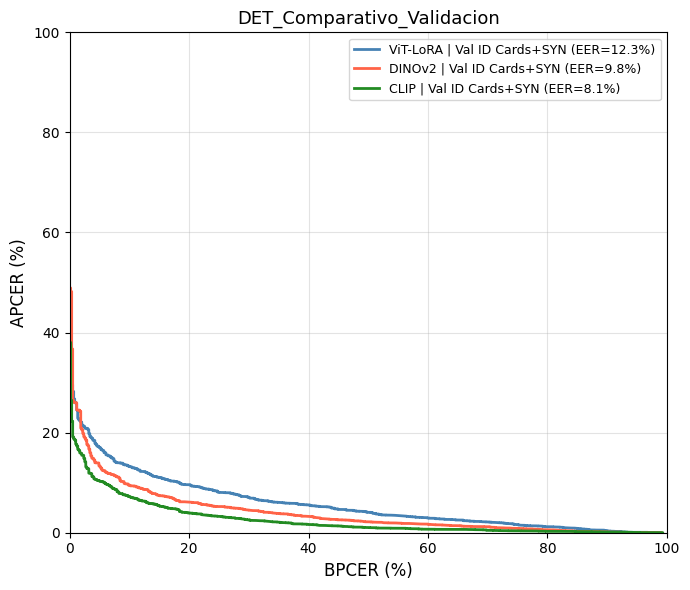

Figura guardada: /content/drive/MyDrive/TFM_ID_Cards/figuras/DET_Comparativo_Validacion.png


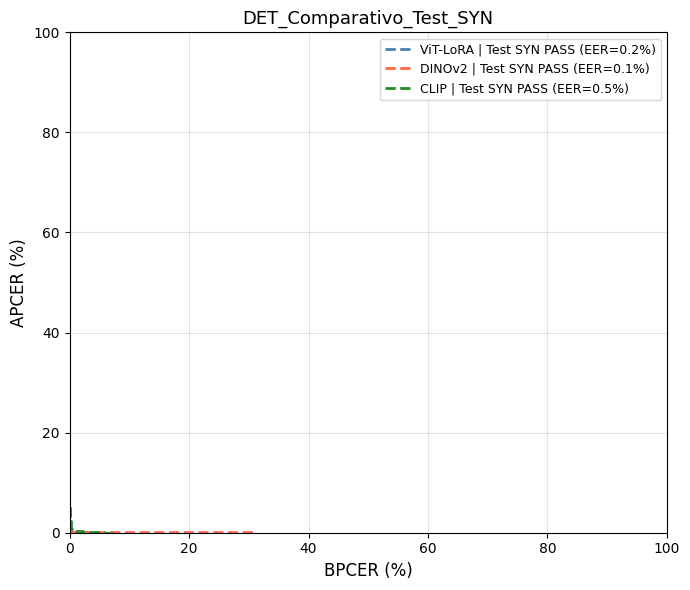

Figura guardada: /content/drive/MyDrive/TFM_ID_Cards/figuras/DET_Comparativo_Test_SYN.png


In [ ]:
def plot_det_comparativo(resultados, titulo='DET Curves Hito 2', split_filter=None):
    """
    Curvas DET superpuestas de todos los modelos.
    """
    fig, ax = plt.subplots(figsize=(7, 6))

    colores = {'ViT-LoRA': 'steelblue', 'DINOv2': 'tomato', 'CLIP': 'forestgreen'}
    estilos = {'Val ID Cards+SYN': '-', 'Test SYN PASS': '--'}

    for key, v in resultados.items():
        modelo_name = key.split(' | ')[0]
        split_name  = key.split(' | ')[1]

        if split_filter and split_name != split_filter:
            continue

        labels = np.array(v['labels'])
        scores = np.array(v['scores'])

        if len(np.unique(labels)) < 2:
            continue

        fpr_d, fnr_d, _ = det_curve(labels, scores, pos_label=1)
        eer_idx = np.argmin(np.abs(fpr_d - fnr_d))
        eer_val = (fpr_d[eer_idx] + fnr_d[eer_idx]) / 2

        ax.plot(
            fpr_d * 100, fnr_d * 100,
            color=colores.get(modelo_name, 'gray'),
            linestyle=estilos.get(split_name, '-'),
            lw=2.0,
            label=f"{key} (EER={eer_val*100:.1f}%)"
        )

    ax.set_xlabel('BPCER (%)', fontsize=12)
    ax.set_ylabel('APCER (%)', fontsize=12)
    ax.set_title(titulo, fontsize=13)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.35)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

    plt.tight_layout()
    fig_path = f'{DRIVE_TFM}/figuras/{titulo.replace(" ", "_")}.png'
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figura guardada: {fig_path}")


plot_det_comparativo(resultados_h2, 'DET_Comparativo_Validacion',
                     split_filter='Val ID Cards+SYN')
plot_det_comparativo(resultados_h2, 'DET_Comparativo_Test_SYN',
                     split_filter='Test SYN PASS')

## Generación del submission para IJCB 2025

El formato que pide el challenge es un CSV con cuatro columnas:
image_path, score, label_pred y label_gt. El score es la probabilidad
de ser ataque (1 = ataque, 0 = genuino), que es la convención más habitual
aunque conviene verificarlo en las instrucciones oficiales antes de subir.

Además del CSV, guardo también un .txt con solo el nombre de archivo y el
score (algunos challenges lo piden así como alternativa) y los arrays .npy
con scores y etiquetas raw para poder recalcular métricas sin relanzar inferencia.

In [ ]:
def generar_submission_ijcb(
    model,
    df_test,
    nombre_modelo,
    output_dir=None,
    score_as_attack=True
):
    if output_dir is None:
        output_dir = f'{DRIVE_TFM}/submissions'
    os.makedirs(output_dir, exist_ok=True)

    loader = DataLoader(
        PADDatasetAlbu(df_test, transform=transform_val_albu),
        batch_size=BATCH_VAL,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=collate_pad,
    )

    model.eval()
    all_scores, all_labels, all_rutas = [], [], []
    rutas_list = df_test['ruta'].tolist()
    ptr = 0

    with torch.no_grad():
        for imgs, labels, _, _ in tqdm(
            loader, desc=f"Generando submission {nombre_modelo}"
        ):
            imgs = imgs.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=torch.float16):
                outputs = model(imgs)
                # igual que en evaluar_modelo_ijcb
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs

            probs = F.softmax(logits.float(), dim=1)[:, 1]

            all_scores.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_rutas.extend(rutas_list[ptr: ptr + imgs.size(0)])
            ptr += imgs.size(0)

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)

    submission_scores = all_scores if score_as_attack else 1 - all_scores
    pred_labels       = (submission_scores >= 0.5).astype(int)

    csv_path = f'{output_dir}/{nombre_modelo}_submission.csv'
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['image_path', 'score', 'label_pred', 'label_gt'])
        for ruta, score, pred, gt in zip(
            all_rutas, submission_scores, pred_labels, all_labels
        ):
            writer.writerow([
                os.path.basename(ruta),
                f'{score:.6f}',
                int(pred),
                int(gt),
            ])

    txt_path = f'{output_dir}/{nombre_modelo}_scores.txt'
    with open(txt_path, 'w') as f:
        for ruta, score in zip(all_rutas, submission_scores):
            f.write(f"{os.path.basename(ruta)} {score:.6f}\n")

    np.save(f'{output_dir}/{nombre_modelo}_scores.npy', all_scores)
    np.save(f'{output_dir}/{nombre_modelo}_labels.npy', all_labels)

    print(f"\nSUBMISSION {nombre_modelo}")
    metrics = calcular_metricas_ijcb(all_labels, all_scores, verbose=True)
    print(f"\nArchivos guardados en: {output_dir}/")
    return metrics


# Genero submissions para los tres modelos sobre el test de SYN PASS
submissions = {}

for modelo, nombre, _ in configs_eval:
    m = generar_submission_ijcb(modelo, test_syn, nombre_modelo=nombre)
    submissions[nombre] = m

print("RANKING FINAL IJCB PAD-ID Card 2025")
print("="*70)
print(f"{'Modelo':<15} {'AVRank':>8} {'BPCER@1%':>10} {'EER':>8}")
print("="*45)
for nombre, m in sorted(submissions.items(), key=lambda x: x[1]['avrank']):
    print(f"{nombre:<15} {m['avrank']:>8.4f} "
          f"{m['bpcer_at_apcer1']:>10.4f} {m['eer']:>8.4f}")

Generando submission ViT-LoRA:   0%|          | 0/25 [00:00<?, ?it/s]


SUBMISSION ViT-LoRA
  Accuracy           : 0.9732
  APCER (thr=0.5)    : 0.0400
  BPCER (thr=0.5)    : 0.0000
  EER                : 0.0025
  BPCER@APCER=10%    : 0.0000
  BPCER@APCER= 5%    : 0.0000
  BPCER@APCER= 1%    : 0.0000
  AVRank             : 0.0000

Archivos guardados en: /content/drive/MyDrive/TFM_ID_Cards/submissions/


Generando submission DINOv2:   0%|          | 0/25 [00:00<?, ?it/s]


SUBMISSION DINOv2
  Accuracy           : 0.9651
  APCER (thr=0.5)    : 0.0522
  BPCER (thr=0.5)    : 0.0000
  EER                : 0.0011
  BPCER@APCER=10%    : 0.0000
  BPCER@APCER= 5%    : 0.0000
  BPCER@APCER= 1%    : 0.0000
  AVRank             : 0.0000

Archivos guardados en: /content/drive/MyDrive/TFM_ID_Cards/submissions/


Generando submission CLIP:   0%|          | 0/25 [00:00<?, ?it/s]


SUBMISSION CLIP
  Accuracy           : 0.9942
  APCER (thr=0.5)    : 0.0070
  BPCER (thr=0.5)    : 0.0033
  EER                : 0.0052
  BPCER@APCER=10%    : 0.0000
  BPCER@APCER= 5%    : 0.0005
  BPCER@APCER= 1%    : 0.0028
  AVRank             : 0.0016

Archivos guardados en: /content/drive/MyDrive/TFM_ID_Cards/submissions/
RANKING FINAL IJCB PAD-ID Card 2025
Modelo            AVRank   BPCER@1%      EER
ViT-LoRA          0.0000     0.0000   0.0025
DINOv2            0.0000     0.0000   0.0011
CLIP              0.0016     0.0028   0.0052


# GUARDADO FINAL Y RESUMEN PARA EL PAPER

In [ ]:
# Guardo todo en JSON
resultados_finales = {
    'experimentos': resultados_h2,
    'submissions': submissions,
    'config': {
        'batch_train': BATCH_TRAIN,
        'grad_accum_steps': 2,
        'img_size': IMG_SIZE,
        'syn_train_ratio': 0.30,
        'seed': SEED,
        'augmentation': 'Albumentations_aggressive',
        'modelos': ['ViT-LoRA', 'DINOv2', 'CLIP'],
    }
}

json_path = f'{DRIVE_TFM}/resultados/hito2_resultados_completos.json'
with open(json_path, 'w') as f:
    json.dump(resultados_finales, f, indent=2)
print(f"Resultados guardados: {json_path}")

# Tabla comparativa legible
filas = []
modelos_orden = sorted(
    ['ViT-LoRA', 'DINOv2', 'CLIP'],
    key=lambda n: resultados_h2[f"{n} | Val ID Cards+SYN"]['metrics']['avrank']
)

for nombre in modelos_orden:
    for split_label, split_key in [
        ('Val',  f"{nombre} | Val ID Cards+SYN"),
        ('Test', f"{nombre} | Test SYN PASS"),
    ]:
        m = resultados_h2[split_key]['metrics']
        filas.append({
            'Modelo'    : nombre,
            'Split'     : split_label,
            'Acc'       : round(m['accuracy'], 4),
            'EER'       : round(m['eer'], 4),
            'BPCER@10%' : round(m['bpcer_at_apcer10'], 4),
            'BPCER@5%'  : round(m['bpcer_at_apcer5'], 4),
            'BPCER@1%'  : round(m['bpcer_at_apcer1'], 4),
            'AVRank'   : round(m['avrank'], 4),
        })

df_final = pd.DataFrame(filas)
print("\nCOMPARATIVA FINAL HITO 2")
print(df_final.to_string(index=False))

# Exportar también a CSV
csv_path = f'{DRIVE_TFM}/resultados/tabla_final_val_test.csv'
df_final.to_csv(csv_path, index=False)
print(f"\nTabla exportada: {csv_path}")
print("\nHito 2 completado.")

Resultados guardados: /content/drive/MyDrive/TFM_ID_Cards/resultados/hito2_resultados_completos.json

COMPARATIVA FINAL HITO 2
  Modelo Split    Acc    EER  BPCER@10%  BPCER@5%  BPCER@1%  AVRank↓
    CLIP   Val 0.9030 0.0812     0.0590    0.1636    0.5076   0.3147
    CLIP  Test 0.9942 0.0052     0.0000    0.0005    0.0028   0.0016
  DINOv2   Val 0.8492 0.0977     0.0911    0.2698    0.7150   0.4567
  DINOv2  Test 0.9651 0.0011     0.0000    0.0000    0.0000   0.0000
ViT-LoRA   Val 0.8685 0.1228     0.1838    0.4384    0.8263   0.5815
ViT-LoRA  Test 0.9732 0.0025     0.0000    0.0000    0.0000   0.0000

Tabla exportada: /content/drive/MyDrive/TFM_ID_Cards/resultados/tabla_final_val_test.csv

Hito 2 completado.


In [ ]:
print(os.listdir('/content/drive/MyDrive/TFM_ID_Cards/check'))

['docker_submission', 'checkpoints']
